[Device] CPU

  2D PINN — Slope Hydrology (FIXED)
  Devices: 107 (Middle) & 108 (Toe)
  Key fix: loss weight rebalancing to resolve R²_val = -3.59


────────────────────────────────────────────────────────────────
[CSV] Loading 2D data: /content/2d_pinn_data_dev_107_108.csv
────────────────────────────────────────────────────────────────
  Device 108: 61954 rows  t=[0.0,2113.1]h
  Device 107: 40783 rows  t=[1.2,1595.5]h
  Sync end   : 1595.5h
  T_MAX_SYNC=1596h  T_MAX_FULL=2118h
  After ds=15: dev108=4131  dev107=2719
  Dev108 θ: [0.0800,0.5393]  mean=0.4465
  Dev107 θ: [0.0800,0.4630]  mean=0.3382

  ┌────────────────────────────────────────────────────────────────┐
  │ 2D PINN Data Summary (FIXED)                                   │
  │ Dev108 Bottom (x=0.135):  4131 pts  θ=[0.080,0.539]  mean=0.4465│
  │ Dev107 Middle (x=0.481):  2719 pts  θ=[0.080,0.463]  mean=0.3382│
  │ Inter-device mean offset: 0.1084  (x-gradient to learn)      │
  │ Sync:  6049 pts  t≤1596h                    

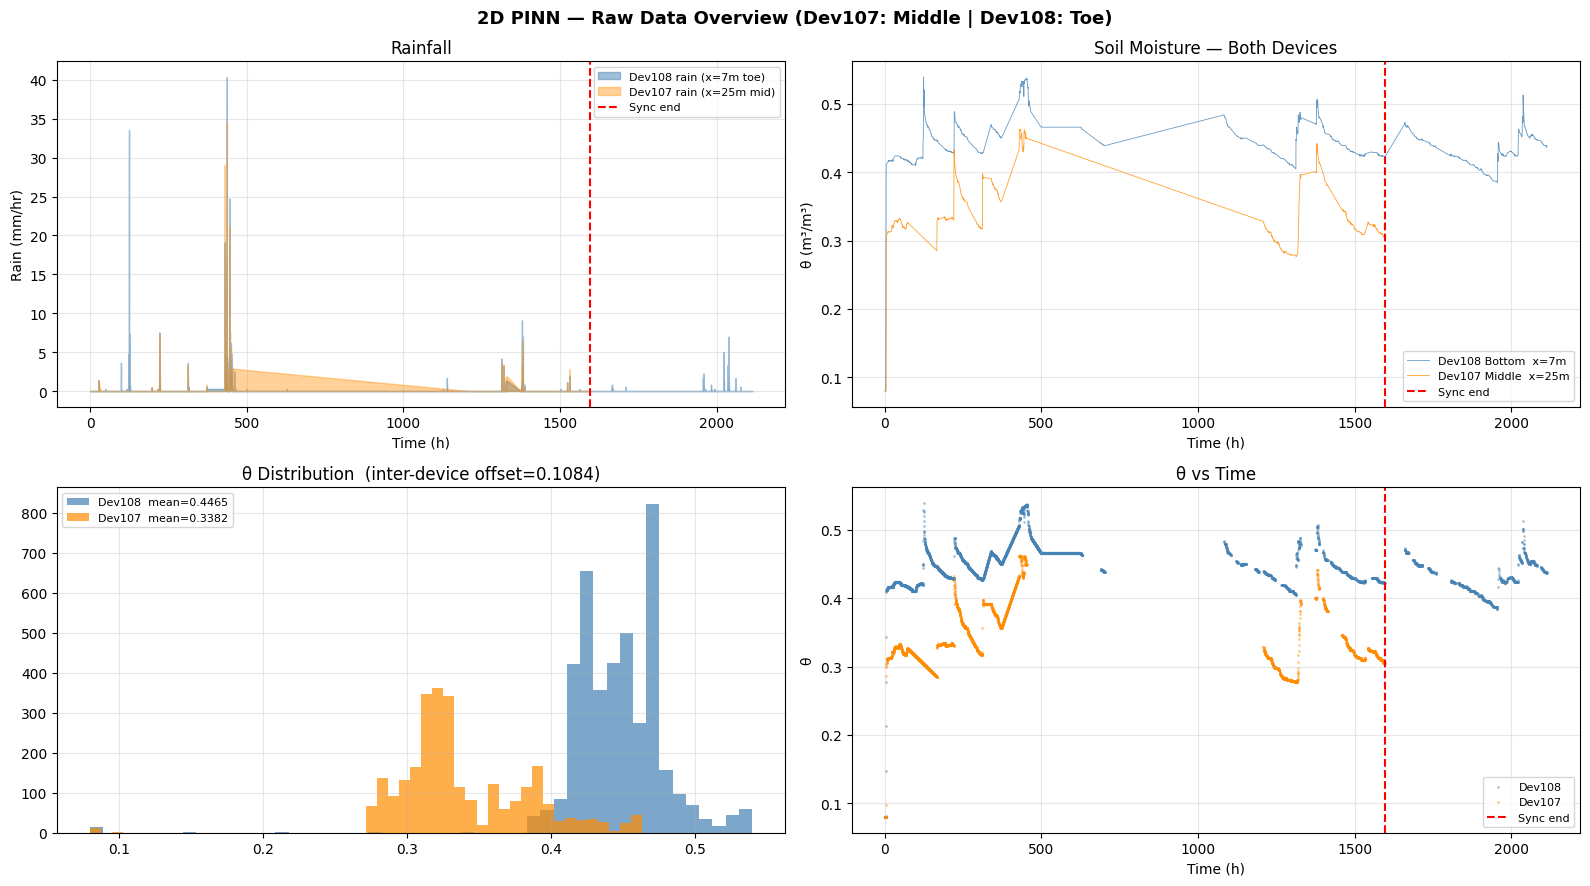

[Plot] Diagnosis → data_diagnosis_2d.png


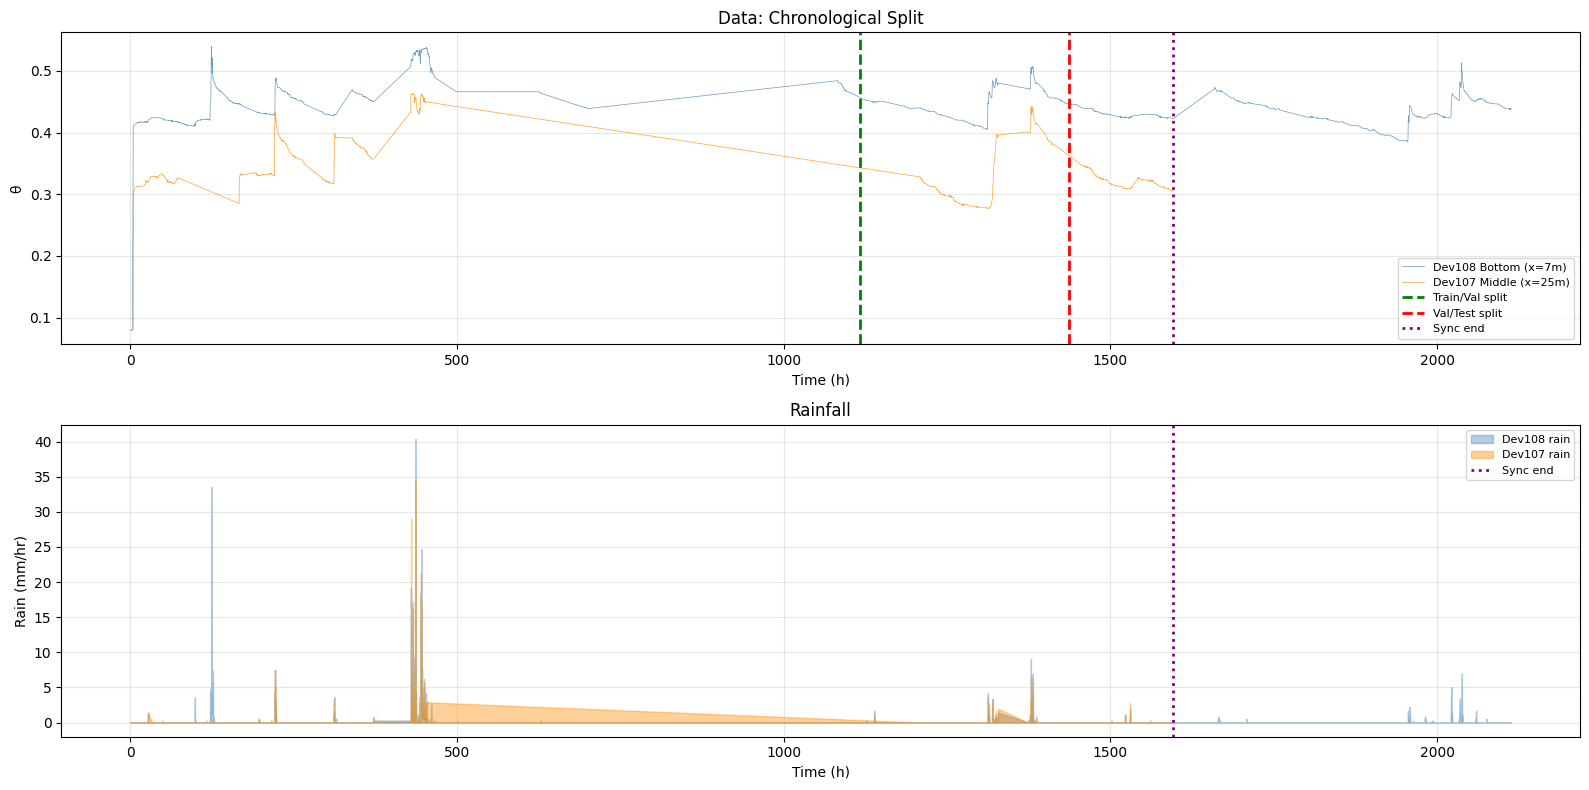

  [IC-psi] theta_ic=0.4173: L1=-4.16m  L2=-19.37m  L3=-0.33m

  STAGE 1 — Physics Discovery (FIXED)

════════════════════════════════════════════════════════════════════════
  2D PINN ENSEMBLE (FIXED)  2 seeds
════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────
  Seed 0  (1/2)
────────────────────────────────────────────────────────────────────────

[PINN2D — FIXED] 2D Slope Hydrology, Devices 107 & 108
  Dev108: x=7m (x_norm=0.135)  Dev107: x=25m (x_norm=0.481)
  Both sensors: z=2.55m (L2 Clay B)
  Inter-device mean offset: ~0.1085 (key x-gradient to learn)
  [IC-psi] theta_ic=0.4173: L1=-4.16m  L2=-19.37m  L3=-0.33m

  ── Stage 1 (FIXED) — sync period, both devices ──────────────────
  Combined sync pts: 6049
  Train:   4234  Val:   1210  Test:    605
  Train108:   2427  Train107:   1807
  obs_max=0.5393  theta_s_L2_init=0.6000
  Inter-device offset: 0.1084  (CRITICAL x-gradient to learn)



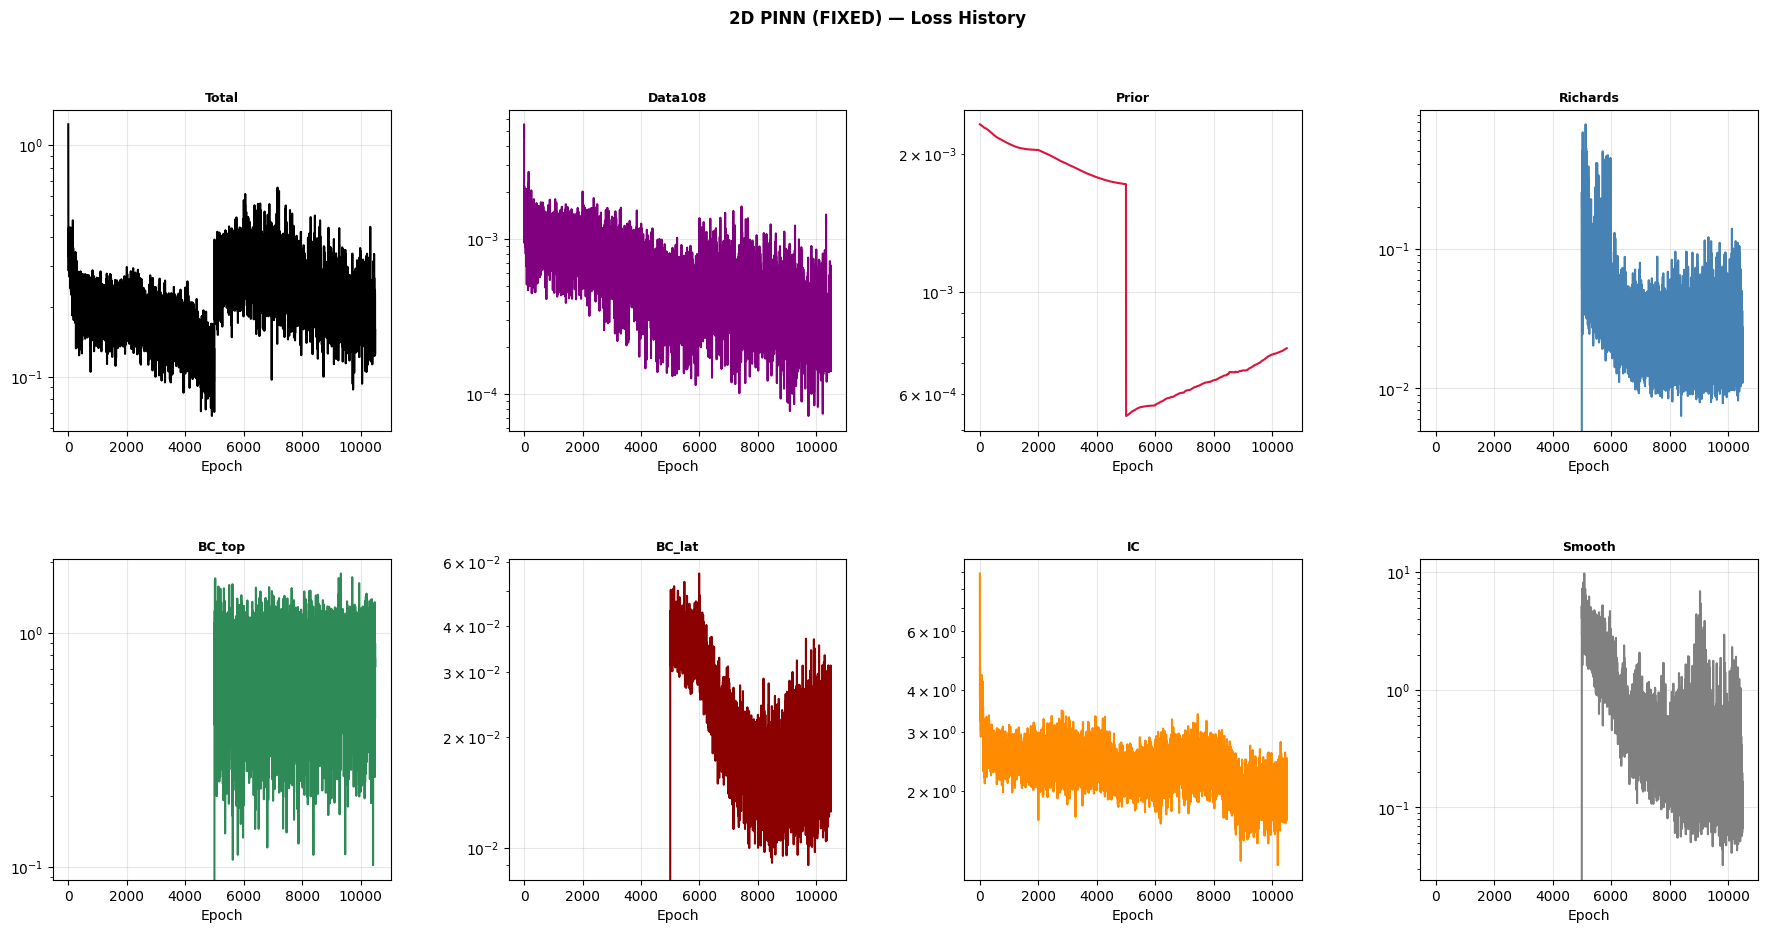

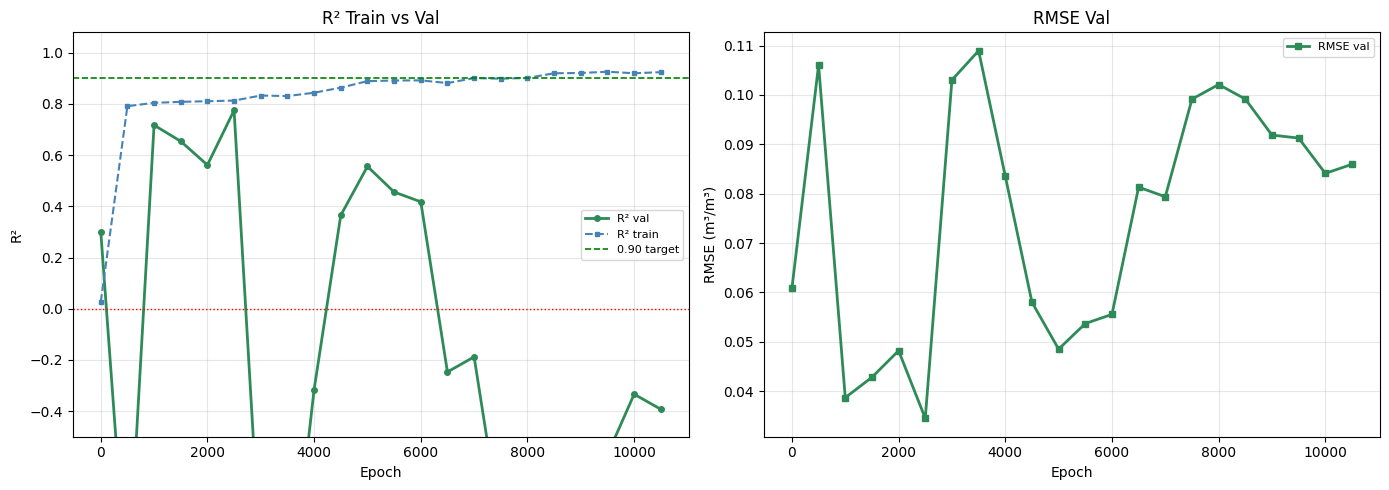

[Plot] Params → inverse_params_2d.png


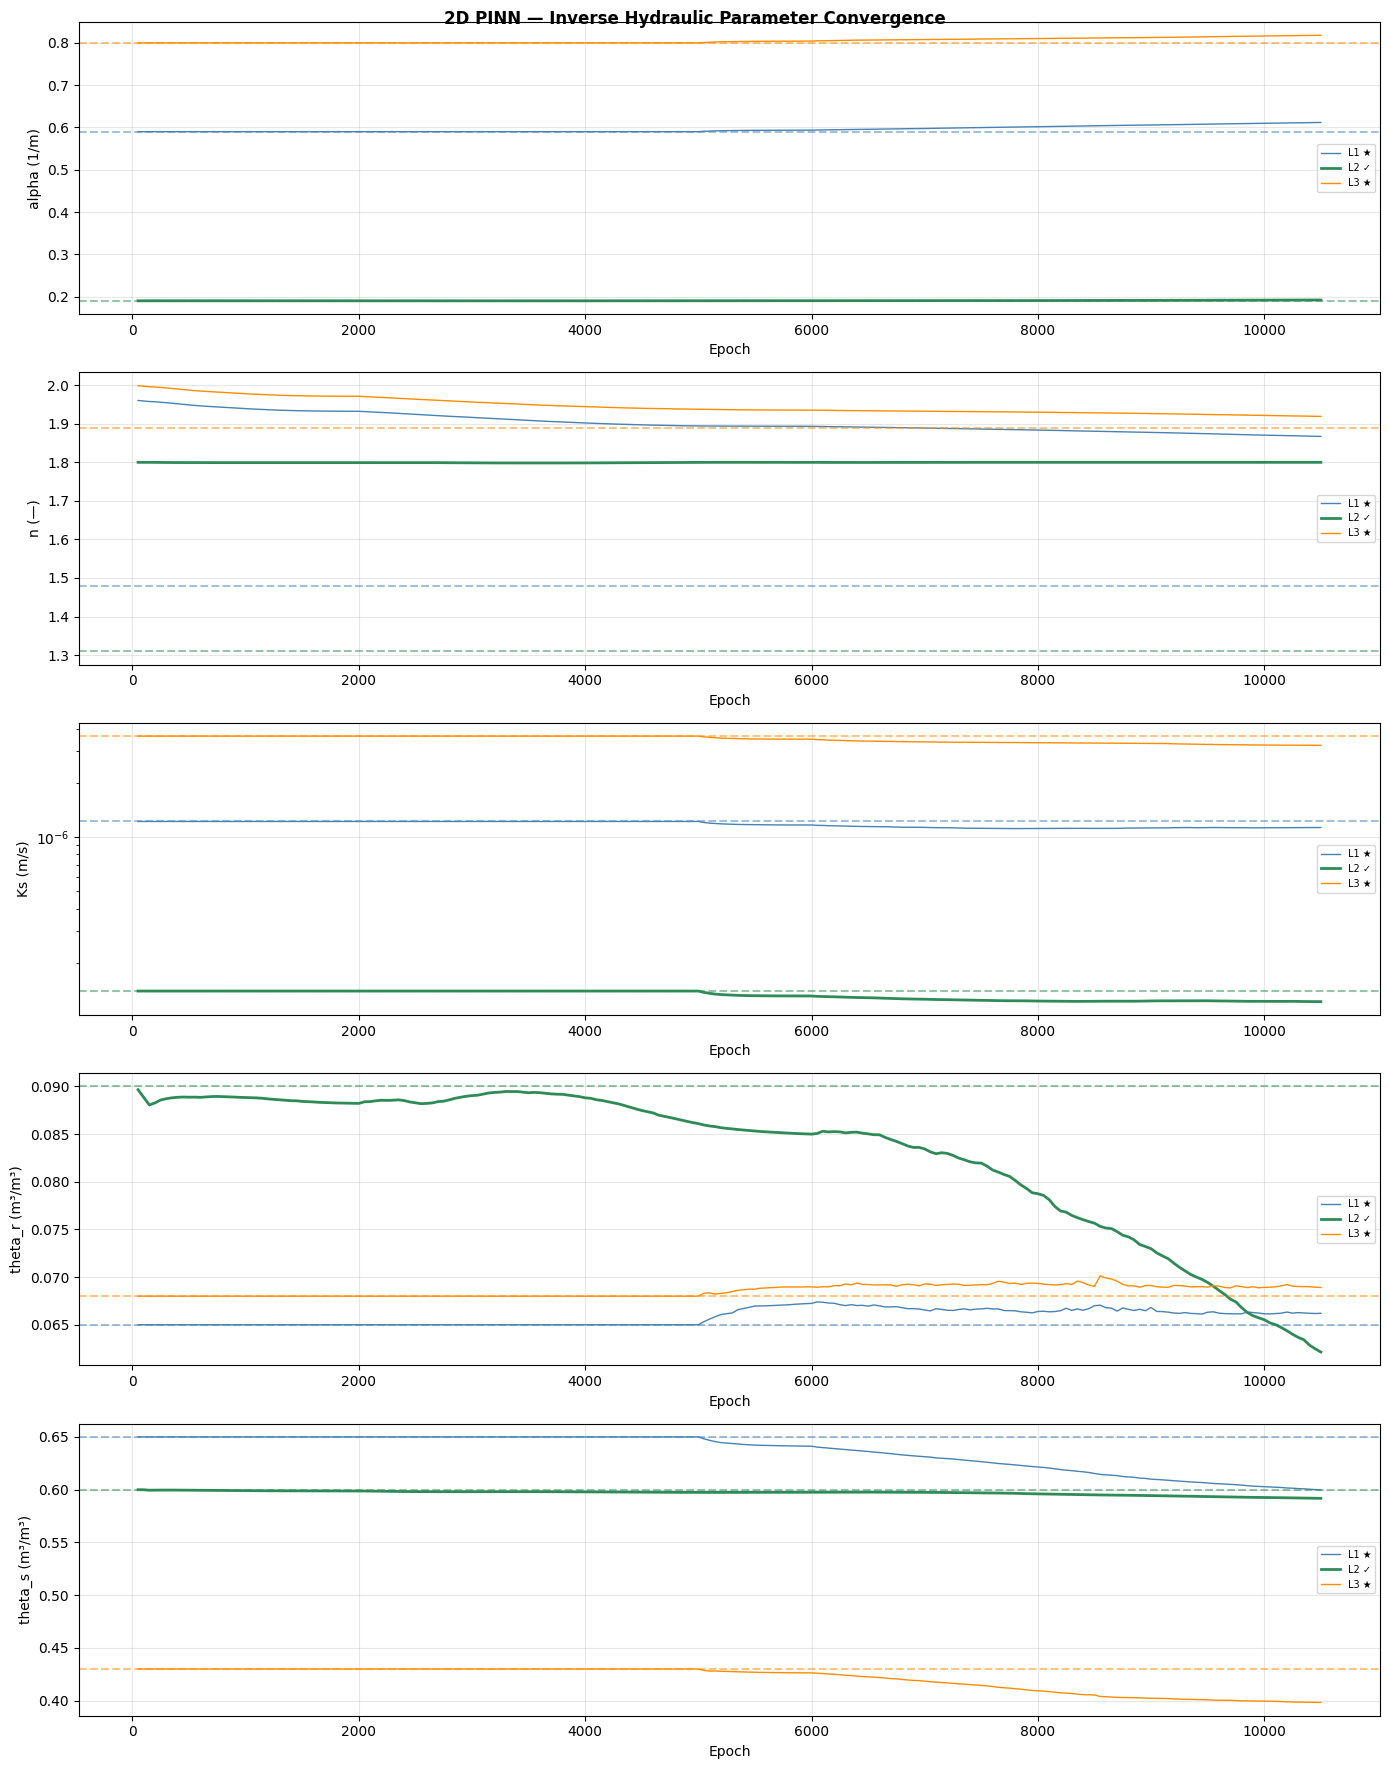

[Plot] Parity → parity_train_2d.png


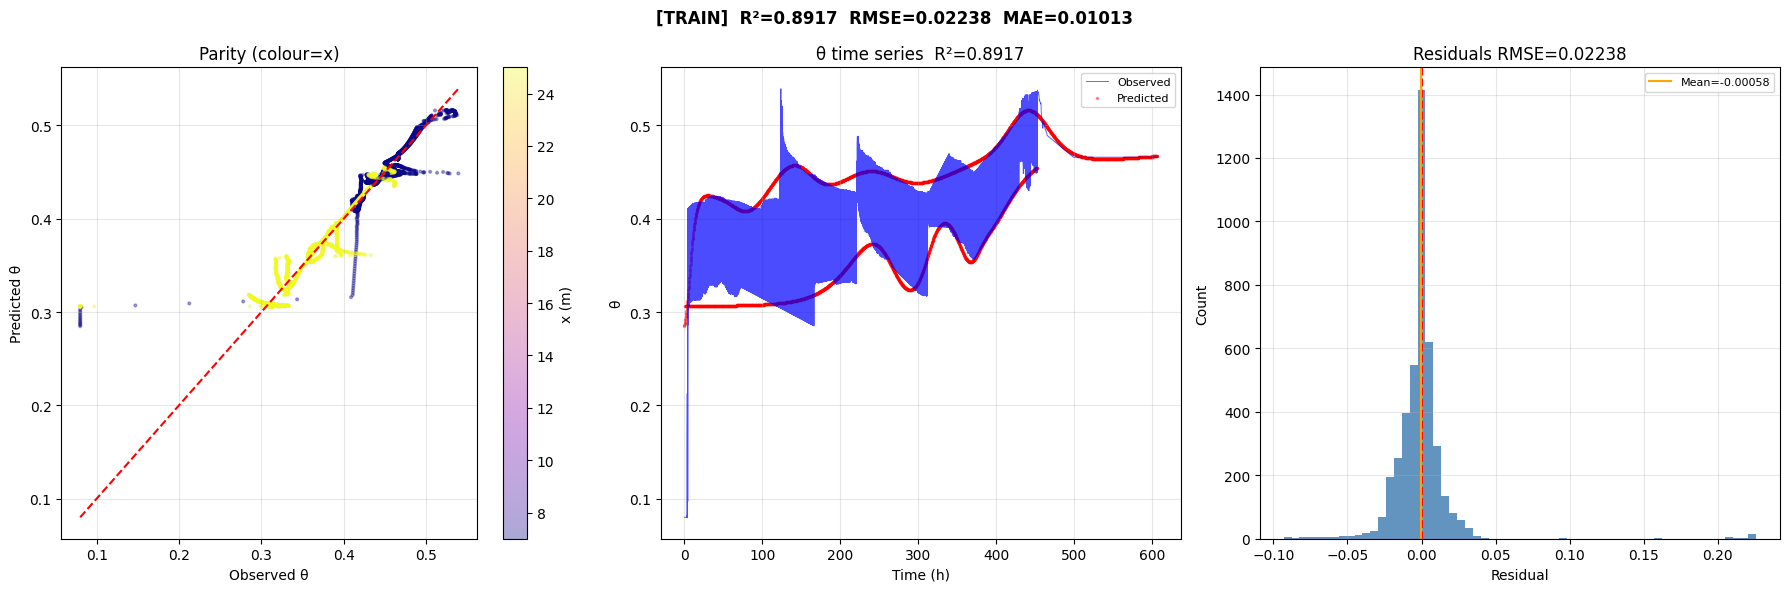

[Plot] Parity → parity_val_2d.png


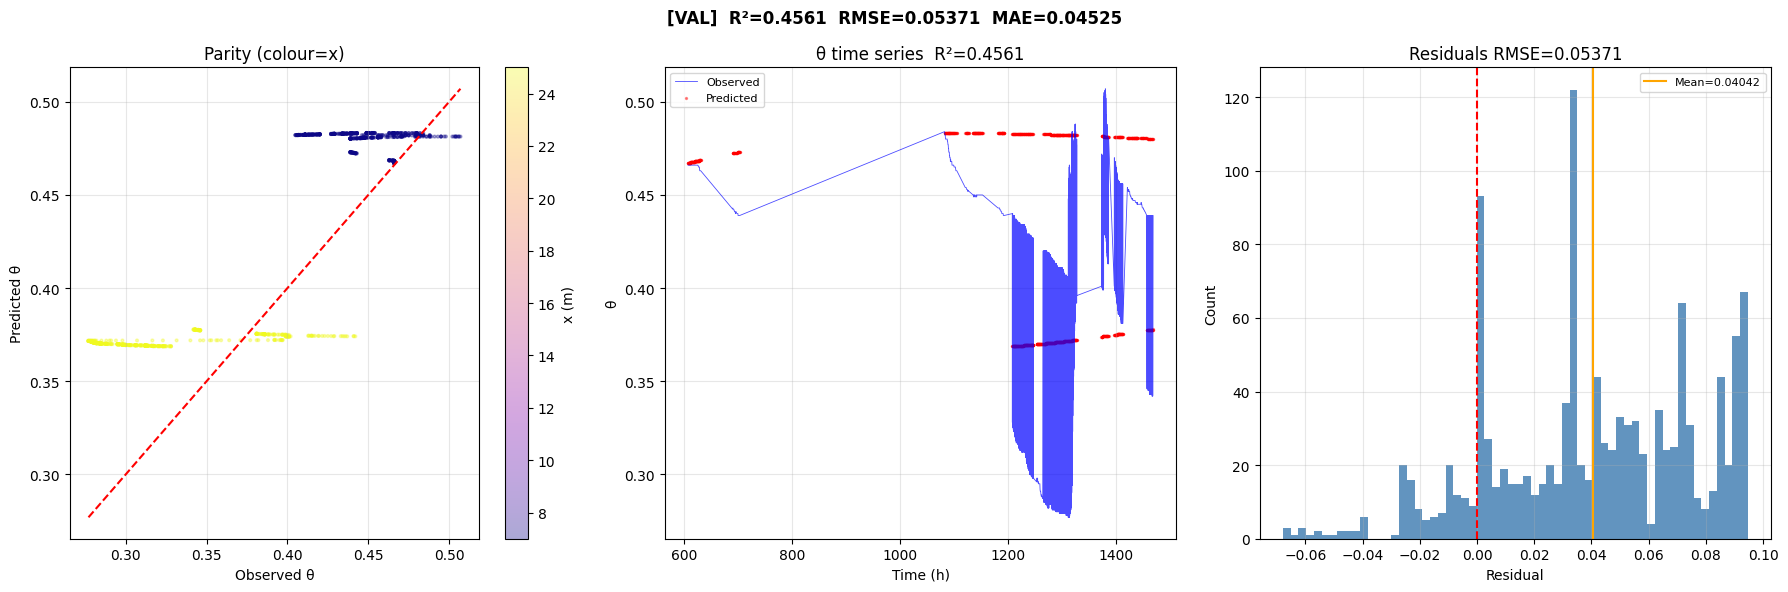

[Plot] Parity → parity_test_2d.png


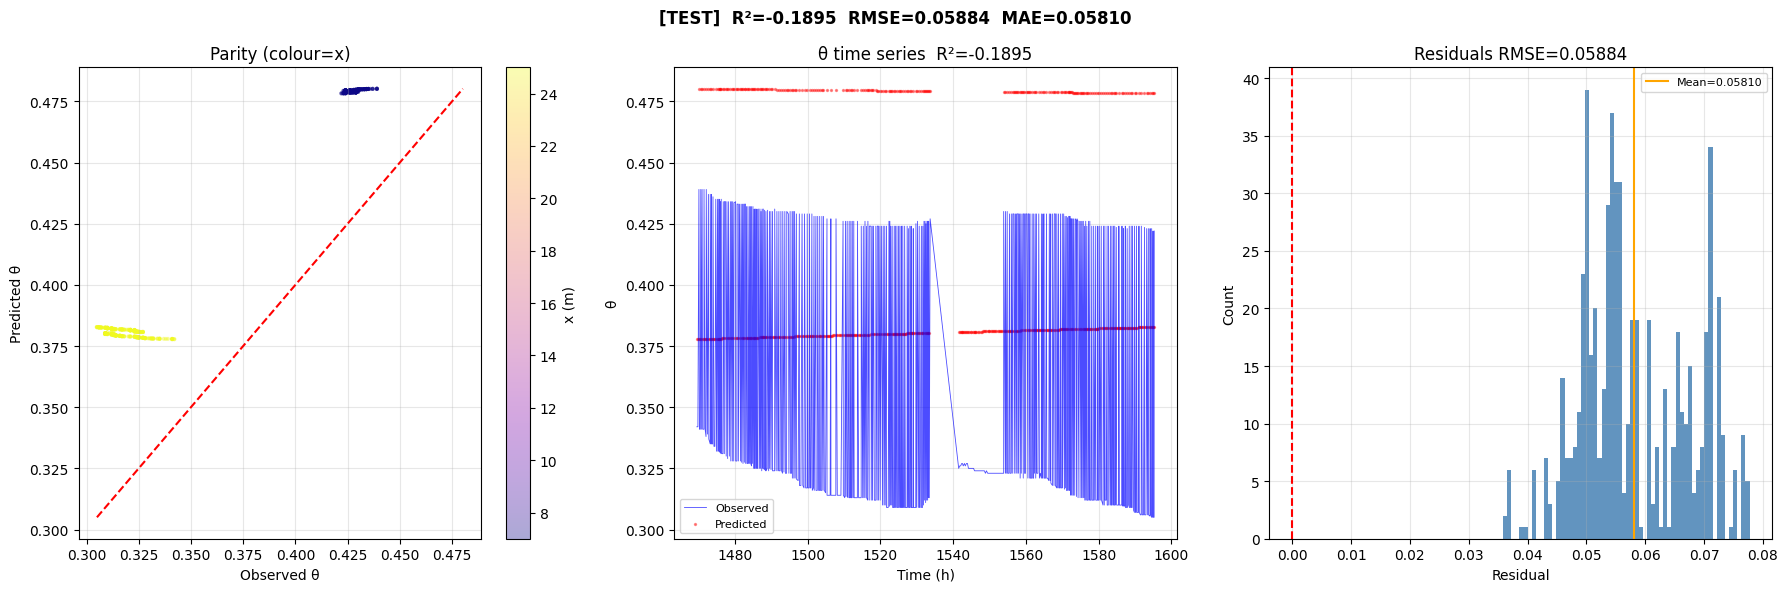

[Plot] 2D heatmap → heatmap_2d.png


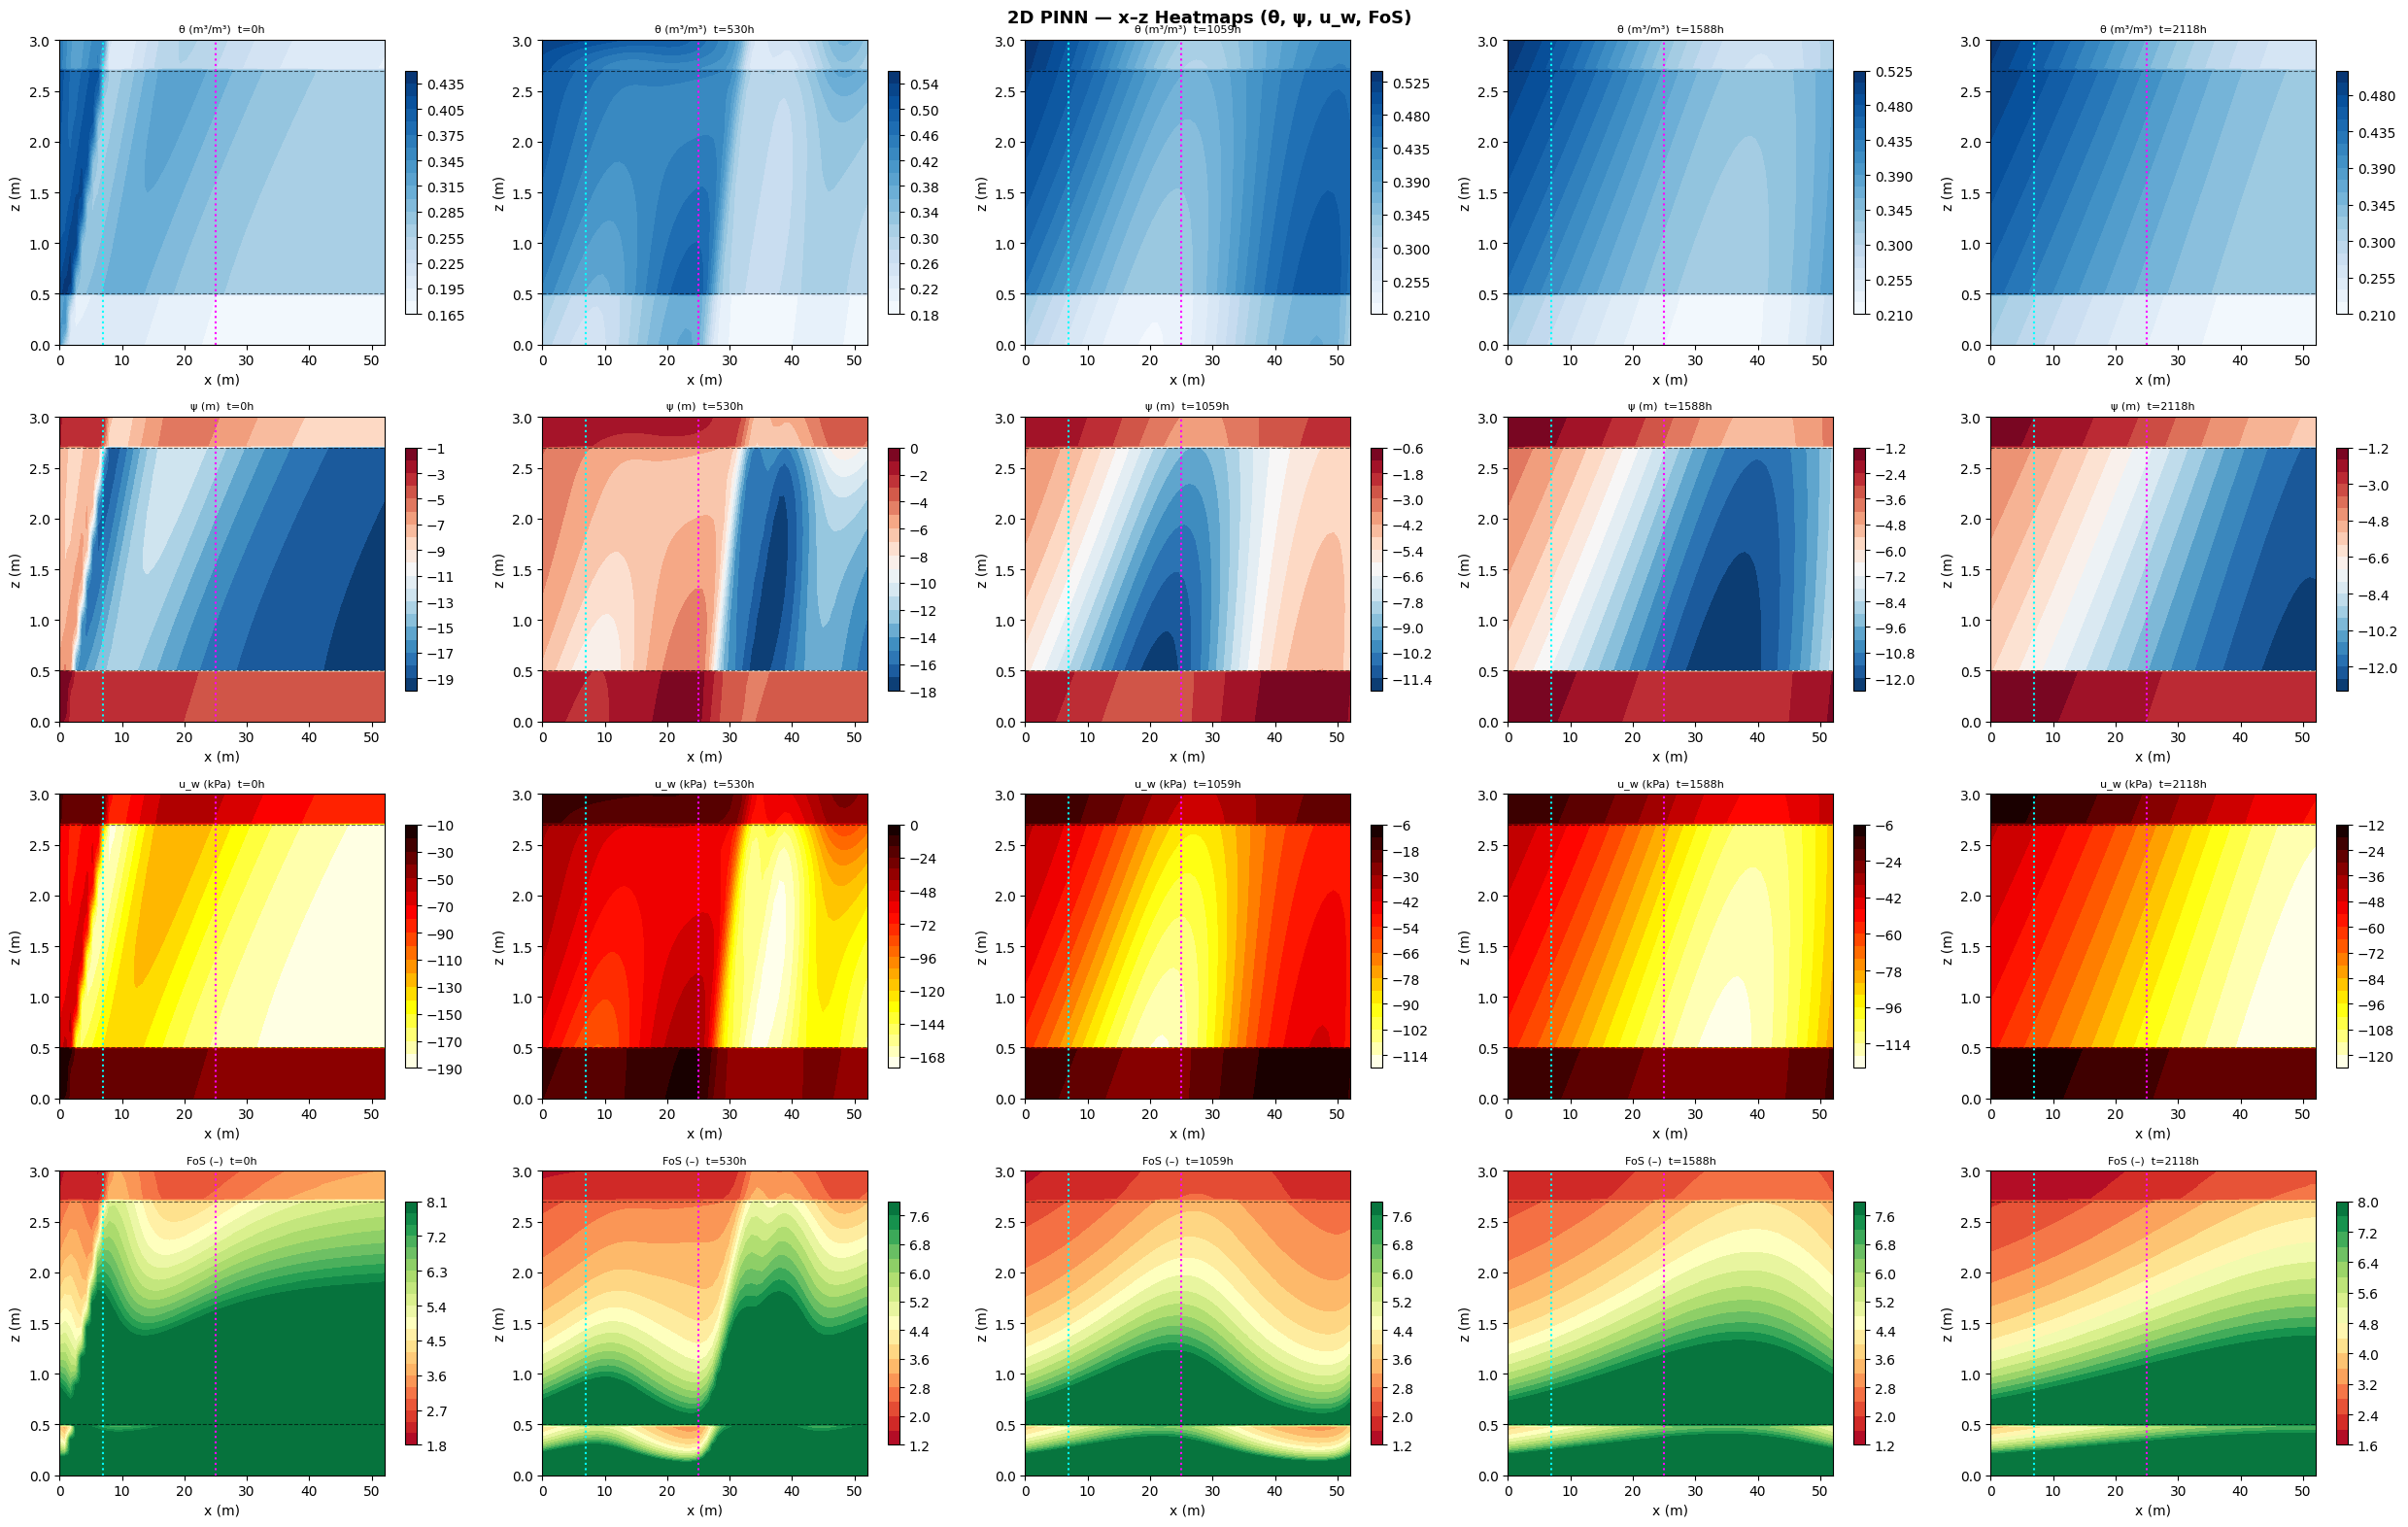

[Plot] Timeseries → timeseries_2d.png


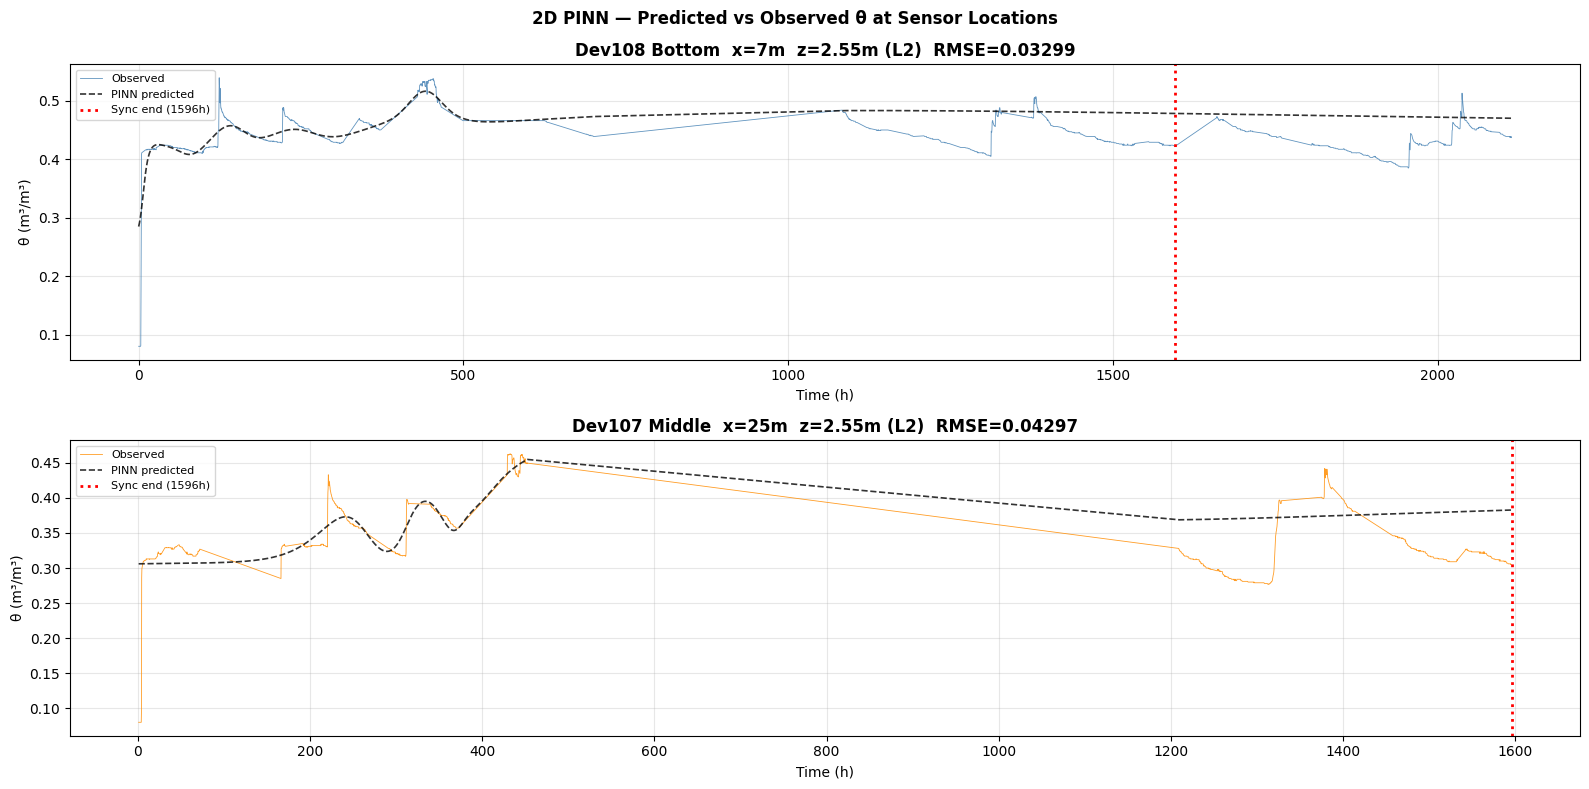

[Plot] FoS profiles → fos_2d_profiles.png


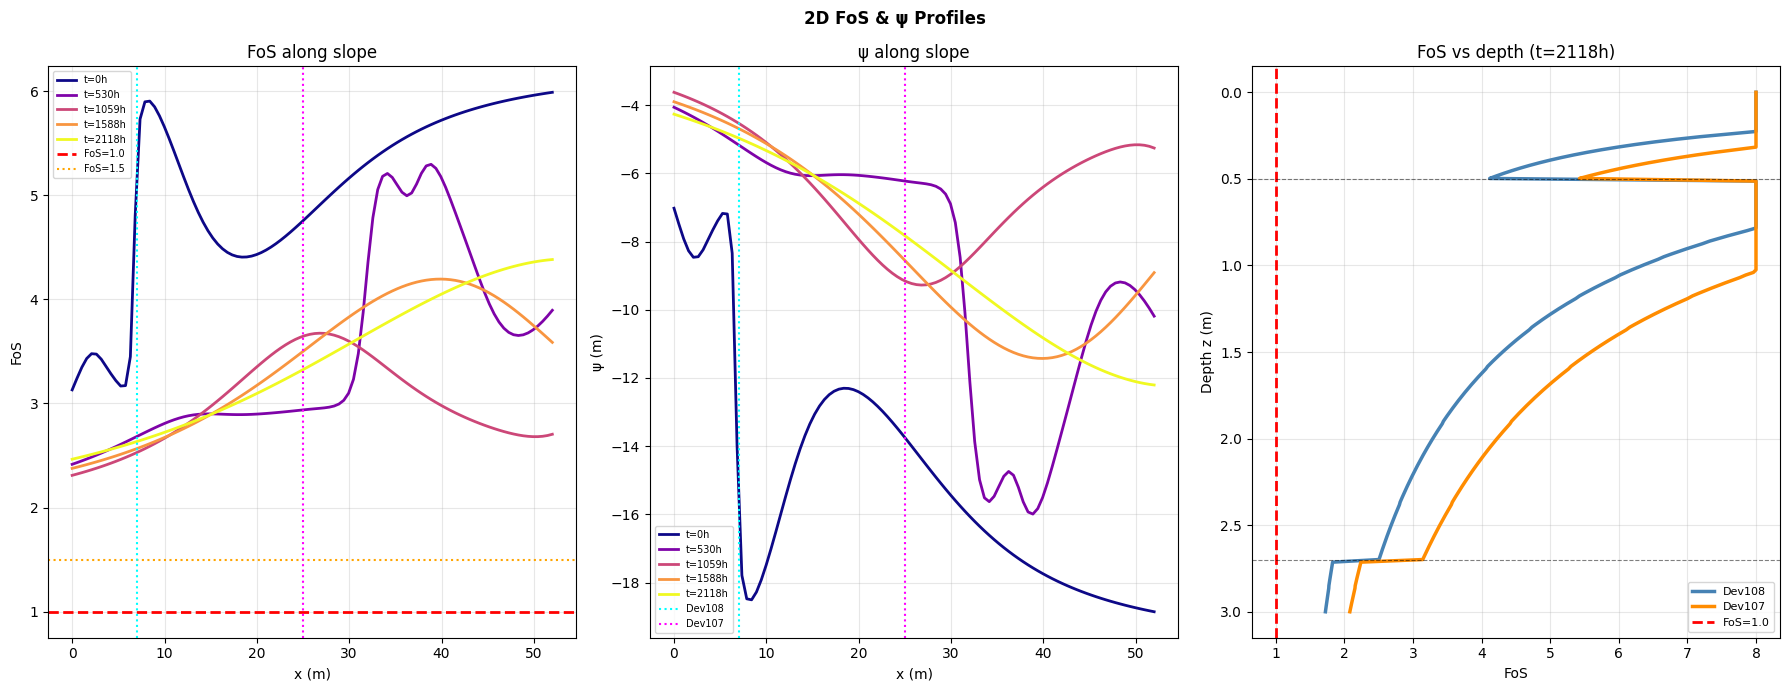


  STAGE 1 RESULTS (FIXED)
  R²   test: -0.3434 ± 0.1539
  RMSE test: 0.06242 ± 0.00359

  Learned VG params (L2 Clay B — DATA-constrained):
    alpha      prior=1.900e-01  learned=1.903e-01  delta=+0.1%
    n          prior=1.310e+00  learned=1.800e+00  delta=+37.4%
    Ks         prior=1.390e-07  learned=1.309e-07  delta=-5.8%
    theta_r    prior=9.000e-02  learned=8.532e-02  delta=-5.2%
    theta_s    prior=6.000e-01  learned=5.975e-01  delta=-0.4%

  STAGE 2 — Rolling Assimilation

  STAGE 2 — Rolling Assimilation  (Device 108, Toe)
  t=[1596h, 2113h]  window=168h  4 windows

  Win   1  t=[1596–1764h]  n=182  naive_rmse=0.01028
     500  PhA   6.896e-02   2.299e-05  0.000e+00  0.000e+00    0.00443  ✓ best
    1000  PhA   7.594e-02   2.531e-05  0.000e+00  0.000e+00    0.00470  Ph-A
    1500  PhA   4.943e-01   1.648e-04  0.000e+00  0.000e+00    0.00315  ✓ best
    2000  PhB   9.082e-02   1.737e-05  2.287e-02  5.411e-02    0.00642  ES 500/1000
    2500  PhB   1.329e-01   3.676e-05  7

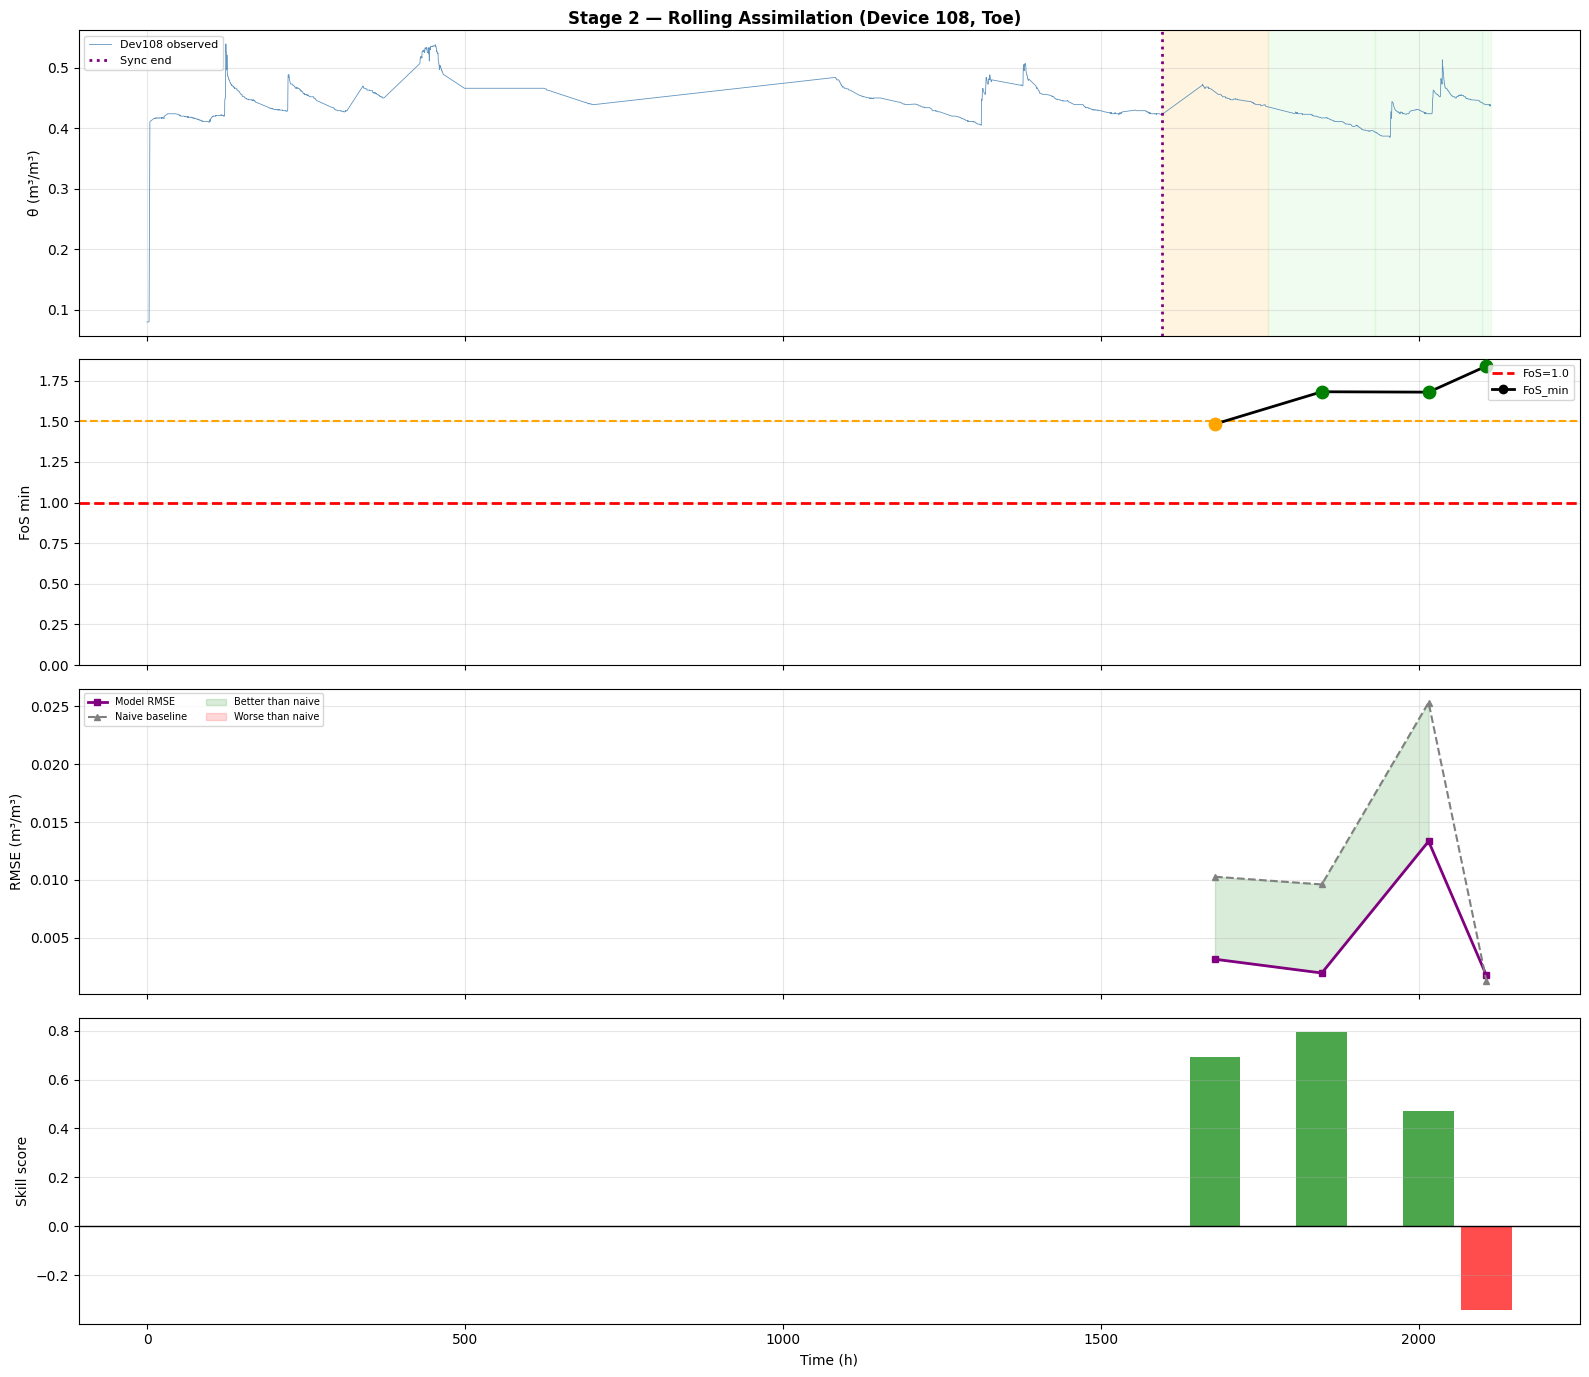


  FINAL SUMMARY (FIXED)
  Stage 1: R²_test=-0.3434  RMSE_test=0.06242
  Stage 2: RMSE mean=0.00505  FoS_worst=1.482  warnings=1  failures=0

  OVERALL VERDICT: EARLY WARNING


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
#  2D PINN — Slope Hydrology  |  Devices 107 (Middle) & 108 (Toe)
#  FIXED VERSION — addresses catastrophic R²_val = -3.59 at ep 8000
#
#  ROOT CAUSES FIXED:
#  ─────────────────────────────────────────────────────────────────────────
#  1. LOSS WEIGHT IMBALANCE (primary cause):
#     Old Phase1: lam_data=1.0  → data gradient ≈ 6.6e-4, prior=1.28e-2
#                 Prior was 20× stronger than data — model learned prior, not data
#     Old Phase2: lam_data=50, but IC loss raw=1.013 with lam_ic=0.1 → 0.10
#                 Data loss = 50×6.6e-4 = 0.033. IC *dominated* data!
#     FIX: Phase1 lam_data=200, Phase2 lam_data=500; lam_ic→0.001, lam_bc→0.001
#
#  2. PRIOR TOO STRONG (secondary cause):
#     lam_prior_nc=0.2 with 15 non-data-constrained params → prior sum >> data
#     FIX: lam_prior_nc=0.02 (Phase1), 0.005 (Phase2)
#
#  3. OFFSET LOSS TOO WEAK:
#     lam_off_ph1=3.0 × offset_raw=3.2e-4 = 9.6e-4 << prior=1.28e-2
#     Model never learned inter-device x-gradient (0.1085 mean offset)
#     FIX: lam_off_ph1=30.0, lam_off_ph2=30.0
#
#  4. IC LOSS NEVER DECAYS:
#     IC loss=1.013 at ep8000 means model fights data with wrong IC forever
#     FIX: IC weight decays exponentially after Phase1 warmup
#
#  5. WARMUP GATE TOO LOW (0.10):
#     Phase2 could enter with R²=0.10 — essentially untrained, then physics
#     immediately destabilizes what little data fit existed
#     FIX: warmup_r2_gate=0.50, and Phase1 now runs longer (5000 epochs)
#
#  6. CSV_FILE path updated for local execution
# ═══════════════════════════════════════════════════════════════════════════

import os
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.autograd import grad as autograd_grad

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(s):
    torch.manual_seed(s)
    np.random.seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark     = True
    torch.backends.cudnn.deterministic = False
    print(f"[Device] GPU → {torch.cuda.get_device_name(0)}"
          f"  ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")
else:
    print("[Device] CPU")

# ── Domain & Geometry ─────────────────────────────────────────────────────
Z_MAX        = 3.0
X_MAX        = 52.0
T_MAX_SYNC   = 1596.0
T_MAX_FULL   = 2114.0
T_MAX        = T_MAX_FULL
SLOPE_ANGLE  = 30.0
RHO_W        = 1000.0
G_ACC        = 9.81

X_POS_108    = 7.0
X_POS_107    = 25.0
X_NORM_108   = X_POS_108 / X_MAX   # ≈ 0.135
X_NORM_107   = X_POS_107 / X_MAX   # ≈ 0.481

SENSOR_DEPTH_108 = 0.45
SENSOR_DEPTH_107 = 0.45

CSV_FILE       = "/content/2d_pinn_data_dev_107_108.csv"
COL_TIME       = "timestamp"
COL_DEVICE     = "devID"
COL_RAIN       = "rain"
COL_SOIL       = "soil"
RAINFALL_UNIT  = "mm/hr"
DOWNSAMPLE_STEP = 15

RAIN_GATE_MS   = 5e-8

# ── THETA CLIP: keep obs_max=0.540 well below theta_s_lo=0.582 ───────────
THETA_CLIP_LO  = 0.08
THETA_CLIP_HI  = 0.545

LAYER_DATA_SUPPORT = {1: False, 2: True, 3: False}
LAYER_NAMES = {
    1: "Sandy CL / A-horizon (L1)  [prior-constrained]",
    2: "Clay B-horizon        (L2)  [DATA-constrained — sensor at z=2.55m]",
    3: "Saprolite C-horizon   (L3)  [prior-constrained]",
}

TIMESTAMP_FORMATS = [
    "%Y-%m-%d %H:%M:%S", "%Y-%m-%d %H:%M",
    "%m/%d/%Y %H:%M", "%d/%m/%Y %H:%M", "%d/%m/%Y %H:%M:%S",
    "%m/%d/%Y %H:%M:%S", "%d-%m-%Y %H:%M",
]

SOIL = {
    1: dict(z_lo=2.7, z_hi=3.0,
            theta_r=0.065, theta_s=0.650, alpha=0.59, n=1.48,
            Ks=1.22e-6,  rho_b=1500.0, c_prime=5.0e3,  phi_prime=30.0),
    2: dict(z_lo=0.5, z_hi=2.7,
            theta_r=0.090, theta_s=0.600, alpha=0.19, n=1.31,
            Ks=1.39e-7,  rho_b=1650.0, c_prime=12.0e3, phi_prime=24.0),
    3: dict(z_lo=0.0, z_hi=0.5,
            theta_r=0.068, theta_s=0.430, alpha=0.80, n=1.89,
            Ks=3.64e-6,  rho_b=1750.0, c_prime=2.0e3,  phi_prime=32.0),
}

PARAM_BOUNDS = {
    "alpha":   [(0.005, 2.0),  (0.01,  2.0),  (0.01,  1.0)],
    "n":       [(1.10,  2.50), (1.05,  1.80), (1.01,  2.00)],
    "Ks":      [(1e-8,  1e-4), (1e-9,  1e-5), (1e-11, 1e-5)],
    "theta_r": [(0.01,  0.10), (0.05,  0.12), (0.05,  0.15)],
    "theta_s": [(0.45,  0.65), (0.582, 0.65), (0.38,  0.55)],
}


# ═══════════════════════════════════════════════════════════════════════════
#  Layer-property helpers
# ═══════════════════════════════════════════════════════════════════════════

def _lp_fixed(z_norm, key):
    z_m = z_norm * Z_MAX
    v1 = float(SOIL[1][key]); v2 = float(SOIL[2][key]); v3 = float(SOIL[3][key])
    return torch.where(z_m >= 2.7, v1*torch.ones_like(z_m),
           torch.where(z_m >= 0.5, v2*torch.ones_like(z_m),
                                   v3*torch.ones_like(z_m)))

def _lp_trainable(z_norm, key, params):
    z_m = z_norm * Z_MAX
    v1, v2, v3 = params[key][0], params[key][1], params[key][2]
    return torch.where(z_m >= 2.7, v1.expand_as(z_m),
           torch.where(z_m >= 0.5, v2.expand_as(z_m),
                                   v3.expand_as(z_m)))

def _lp(z, key, params=None):
    return _lp_trainable(z, key, params) if params is not None else _lp_fixed(z, key)


# ═══════════════════════════════════════════════════════════════════════════
#  Van Genuchten functions
# ═══════════════════════════════════════════════════════════════════════════

def vg_Se(psi, z, params=None):
    alpha = _lp(z, "alpha", params); n = _lp(z, "n", params)
    m = 1.0 - 1.0/n
    arg = torch.clamp(alpha*torch.abs(psi), min=0.0)
    Se = 1.0/(1.0+arg.pow(n)).pow(m)
    Se = torch.where(psi >= 0.0, torch.ones_like(psi), Se)
    return torch.clamp(Se, 1e-6, 1.0-1e-6)

def vg_K(psi, z, params=None):
    Ks = _lp(z, "Ks", params); n = _lp(z, "n", params)
    m = 1.0 - 1.0/n
    Se = vg_Se(psi, z, params)
    inner = torch.clamp(1.0-torch.clamp(Se, 1e-6, 1-1e-6).pow(1.0/m), min=0.0)
    K = Ks*Se.pow(0.5)*(1.0-inner.pow(m)).pow(2.0)
    return torch.clamp(K, 1e-15, 1e-2)

def dtheta_dpsi(psi, z, params=None):
    alpha = _lp(z, "alpha", params); n = _lp(z, "n", params)
    m = 1.0 - 1.0/n
    dts = _lp(z, "theta_s", params) - _lp(z, "theta_r", params)
    arg = torch.clamp(alpha*torch.abs(psi), min=0.0)
    C = dts*m*n*alpha*arg.pow(n-1.0)/(1.0+arg.pow(n)).pow(m+1.0)
    C = torch.where(psi >= 0.0, torch.zeros_like(psi), C)
    return torch.clamp(C, 0.0, 10.0)


# ═══════════════════════════════════════════════════════════════════════════
#  Hydromechanical coupling
# ═══════════════════════════════════════════════════════════════════════════

def pore_pressure(psi):
    return torch.clamp(RHO_W * G_ACC * psi, -5e5, 5e5)

def overburden_stress(z_norm):
    z_m   = z_norm * Z_MAX
    N     = z_m.shape[0]
    n_q   = 20
    frac  = torch.linspace(0.0, 1.0, n_q, device=z_m.device).unsqueeze(0)
    z_int = z_m * frac
    rho_at = _lp_fixed(z_int.reshape(-1,1)/Z_MAX, "rho_b").reshape(N, n_q)
    sigma_v = rho_at.mean(dim=1, keepdim=True) * G_ACC * z_m
    return torch.clamp(sigma_v, min=0.0)

def compute_hydromech_chain(psi, z_norm, slope_rad):
    u_w     = pore_pressure(psi)
    sigma_v = overburden_stress(z_norm)
    cos2a   = np.cos(slope_rad)**2
    sincos  = np.sin(slope_rad)*np.cos(slope_rad)
    sp_n    = torch.clamp(sigma_v*cos2a - u_w, min=0.0)
    tau     = sigma_v*sincos + 1e-3
    c_p     = _lp(z_norm, "c_prime")
    phi_p   = _lp(z_norm, "phi_prime")*(np.pi/180.0)
    fos     = torch.clamp((c_p + sp_n*torch.tan(phi_p))/tau, 0.0, 20.0)
    return u_w, sigma_v, sp_n, tau, fos


# ═══════════════════════════════════════════════════════════════════════════
#  2D Neural Network
# ═══════════════════════════════════════════════════════════════════════════

def _softplus_inv(y):
    y_np = np.asarray(y, dtype=np.float64)
    return float(np.log(np.expm1(np.clip(y_np, 1e-6, None)) + 1e-10))


class PINN2D(nn.Module):
    def __init__(self, hidden=6, width=128):
        super().__init__()
        layers = [nn.Linear(3, width), nn.Tanh()]
        for _ in range(hidden-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        self.trunk    = nn.Sequential(*layers)
        self.head_psi = nn.Linear(width, 1)
        self._init_weights()

        def _ip(key):
            return nn.Parameter(torch.tensor(
                [SOIL[i][key] for i in [1,2,3]], dtype=torch.float32))
        self._log_alpha   = nn.Parameter(torch.log(_ip("alpha").data))
        self._log_Ks      = nn.Parameter(torch.log(_ip("Ks").data))
        self._raw_n       = nn.Parameter(_ip("n").data - 1.0)
        self._raw_theta_r = nn.Parameter(_ip("theta_r").data)
        self._raw_theta_s = nn.Parameter(_ip("theta_s").data)

        with torch.no_grad():
            self._raw_theta_s.data[1] = max(float(self._raw_theta_s.data[1]), 0.582)

        print("\n[PINN2D — FIXED] 2D Slope Hydrology, Devices 107 & 108")
        print(f"  Dev108: x={X_POS_108:.0f}m (x_norm={X_NORM_108:.3f})  Dev107: x={X_POS_107:.0f}m (x_norm={X_NORM_107:.3f})")
        print(f"  Both sensors: z=2.55m (L2 Clay B)")
        print(f"  Inter-device mean offset: ~0.1085 (key x-gradient to learn)")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    @property
    def hydro_params(self):
        alpha   = torch.exp(self._log_alpha)
        Ks      = torch.exp(self._log_Ks)
        n_raw   = 1.0 + F.softplus(self._raw_n)
        n_lo    = torch.tensor([PARAM_BOUNDS["n"][i][0] for i in range(3)],
                               dtype=torch.float32, device=self._raw_n.device)
        n_hi    = torch.tensor([PARAM_BOUNDS["n"][i][1] for i in range(3)],
                               dtype=torch.float32, device=self._raw_n.device)
        n       = torch.max(torch.min(n_raw, n_hi), n_lo)
        theta_r = torch.clamp(self._raw_theta_r, 0.01, 0.12)
        ts_lo   = torch.tensor([PARAM_BOUNDS["theta_s"][i][0] for i in range(3)],
                               dtype=torch.float32, device=self._raw_theta_s.device)
        ts_hi   = torch.tensor([PARAM_BOUNDS["theta_s"][i][1] for i in range(3)],
                               dtype=torch.float32, device=self._raw_theta_s.device)
        theta_s = torch.max(torch.min(self._raw_theta_s, ts_hi), ts_lo)
        theta_s = torch.max(theta_s, theta_r.detach() + 0.05)
        return {"alpha": alpha, "n": n, "Ks": Ks,
                "theta_r": theta_r, "theta_s": theta_s}

    def clamp_params_(self):
        with torch.no_grad():
            for li in range(3):
                lo, hi = PARAM_BOUNDS["alpha"][li]
                self._log_alpha.data[li].clamp_(np.log(lo), np.log(hi))
                lo, hi = PARAM_BOUNDS["Ks"][li]
                self._log_Ks.data[li].clamp_(np.log(lo), np.log(hi))
                lo, hi = PARAM_BOUNDS["n"][li]
                self._raw_n.data[li].clamp_(_softplus_inv(lo-1.0), _softplus_inv(hi-1.0))
                lo, hi = PARAM_BOUNDS["theta_r"][li]
                self._raw_theta_r.data[li].clamp_(lo, hi)
                lo, hi = PARAM_BOUNDS["theta_s"][li]
                self._raw_theta_s.data[li].clamp_(lo, hi)

    def get_learned_params(self):
        return {k: v.detach().cpu().numpy() for k, v in self.hydro_params.items()}

    def forward(self, x, z, t):
        feat    = self.trunk(torch.cat([x, z, t], dim=1))
        z_m     = z * Z_MAX
        raw_psi = self.head_psi(feat)
        scale = torch.where(z_m >= 2.7,  6.0*torch.ones_like(z_m),
                torch.where(z_m >= 0.5, 12.0*torch.ones_like(z_m),
                                         3.0*torch.ones_like(z_m)))
        shift = torch.where(z_m >= 2.7, -5.0*torch.ones_like(z_m),
                torch.where(z_m >= 0.5,-11.0*torch.ones_like(z_m),
                                        -2.5*torch.ones_like(z_m)))
        psi     = scale*torch.tanh(raw_psi) + shift
        p       = self.hydro_params
        theta_r = _lp(z, "theta_r", p)
        theta_s = _lp(z, "theta_s", p)
        Se      = vg_Se(psi, z, p)
        theta_d = theta_r + (theta_s - theta_r) * Se
        return psi, theta_d


# ═══════════════════════════════════════════════════════════════════════════
#  Rain function
# ═══════════════════════════════════════════════════════════════════════════

_q_rain_fn_2d = None

def get_q_rain_2d():
    if _q_rain_fn_2d is None:
        raise RuntimeError("[get_q_rain_2d] Not set.")
    return _q_rain_fn_2d


# ═══════════════════════════════════════════════════════════════════════════
#  IC support
# ═══════════════════════════════════════════════════════════════════════════

_psi_ic_cache = None

def _compute_psi_ic_from_data(loader):
    global _psi_ic_cache
    th108 = loader.theta_obs_108.cpu().numpy().flatten()
    t108  = loader.t_obs_norm_108.cpu().numpy().flatten()
    cutoff   = np.quantile(t108, 0.05)
    th_early = th108[t108 <= cutoff]
    th_ic    = float(np.median(th_early)) if len(th_early) > 0 else float(np.median(th108))
    th_ic    = np.clip(th_ic, THETA_CLIP_LO + 0.01, THETA_CLIP_HI - 0.01)
    psi_by_layer = {}
    for li, s in SOIL.items():
        tr, ts = s["theta_r"], s["theta_s"]
        Se  = np.clip((th_ic - tr) / max(ts - tr, 1e-6), 1e-6, 1-1e-6)
        al  = s["alpha"]; nv = s["n"]; mv = 1 - 1/nv
        psi = -(1/al) * (Se**(-1/mv) - 1)**(1/nv)
        psi_by_layer[li] = float(np.clip(psi, -20.0, -0.01))
    _psi_ic_cache = psi_by_layer
    print(f"  [IC-psi] theta_ic={th_ic:.4f}: "
          f"L1={psi_by_layer[1]:.2f}m  L2={psi_by_layer[2]:.2f}m  L3={psi_by_layer[3]:.2f}m")
    return psi_by_layer


def psi_initial(z_norm):
    z_m = z_norm * Z_MAX
    p1, p2, p3 = (-8.0, -6.0, -3.0) if _psi_ic_cache is None else \
                 (_psi_ic_cache[1], _psi_ic_cache[2], _psi_ic_cache[3])
    return torch.where(z_m >= 2.7, p1*torch.ones_like(z_m),
           torch.where(z_m >= 0.5, p2*torch.ones_like(z_m),
                                   p3*torch.ones_like(z_m)))


# ═══════════════════════════════════════════════════════════════════════════
#  Importance sampler
# ═══════════════════════════════════════════════════════════════════════════

_rain_cdf = None

def build_rain_sampler(t_rain_h, q_rain_ms):
    global _rain_cdf
    t_n = (t_rain_h.cpu().numpy() / T_MAX).astype(np.float64)
    q   = q_rain_ms.cpu().numpy().astype(np.float64)
    w   = q + 0.05*q.max()
    cdf = np.cumsum(w); cdf /= cdf[-1]
    _rain_cdf = (t_n, cdf)

def _importance_t(n):
    if _rain_cdf is None:
        return torch.rand(n, 1, device=device)
    t_arr, cdf = _rain_cdf
    t_s = np.interp(np.random.rand(n), cdf, t_arr).astype(np.float32)
    return torch.tensor(t_s, device=device).unsqueeze(1)


# ═══════════════════════════════════════════════════════════════════════════
#  Collocation sampling
# ═══════════════════════════════════════════════════════════════════════════

def sample_pts_2d(n_int, n_bc, n_ic, use_importance=True):
    def rn(n): return torch.rand(n, 1, device=device)
    def ze(n): return torch.zeros(n, 1, device=device)
    def on(n): return torch.ones(n, 1, device=device)
    def rt(n): return _importance_t(n) if use_importance else rn(n)
    def rq(*ts): return tuple(t.requires_grad_(True) for t in ts)

    nb2 = max(n_bc // 2, 1)
    return dict(
        int   = rq(rn(n_int), rn(n_int), rt(n_int)),
        ic    = rq(rn(n_ic),  rn(n_ic),  ze(n_ic)),
        top   = rq(rn(n_bc),  on(n_bc),  rt(n_bc)),
        bot   = rq(rn(n_bc),  ze(n_bc),  rt(n_bc)),
        left  = rq(ze(nb2),   rn(nb2),  rt(nb2)),
        right = rq(on(nb2),   rn(nb2),  rt(nb2)),
    )


# ═══════════════════════════════════════════════════════════════════════════
#  Gradient helper
# ═══════════════════════════════════════════════════════════════════════════

def _grad(y, v):
    return autograd_grad(y, v, grad_outputs=torch.ones_like(y),
                         create_graph=True, retain_graph=True)[0]

def safe_sq(res, name=""):
    val = torch.mean(res**2)
    if not torch.isfinite(val):
        print(f"  ⚠  NaN/Inf in '{name}'")
        return torch.tensor(0.0, device=device, requires_grad=True)
    return val


# ═══════════════════════════════════════════════════════════════════════════
#  Physics losses
# ═══════════════════════════════════════════════════════════════════════════

def loss_richards_2d(model, x, z, t):
    p        = model.hydro_params
    psi, _   = model(x, z, t)
    K        = vg_K(psi, z, p)
    C        = dtheta_dpsi(psi, z, p)
    T_MAX_S  = T_MAX * 3600.0

    dpsi_dz_phys = _grad(psi, z) / Z_MAX
    dpsi_dx_phys = _grad(psi, x) / X_MAX
    dpsi_dt_phys = _grad(psi, t) / T_MAX_S

    q_z      = K * (dpsi_dz_phys + 1.0)
    dqz_dz   = _grad(q_z, z) / Z_MAX
    q_x      = K * dpsi_dx_phys
    dqx_dx   = _grad(q_x, x) / X_MAX

    res      = C * dpsi_dt_phys - dqz_dz - dqx_dx
    Ks_ref   = float(SOIL[1]["Ks"])
    return safe_sq(res / Ks_ref, "richards_2d")


def loss_ic_2d(model, x, z, t):
    psi, _ = model(x, z, t)
    psi_0  = psi_initial(z)
    return safe_sq((psi - psi_0) / (Z_MAX + 1e-6), "ic_psi")


def loss_bc_top_2d(model, x, z, t):
    p            = model.hydro_params
    psi, _       = model(x, z, t)
    K            = vg_K(psi, z, p)
    dpsi_dz_phys = _grad(psi, z) / Z_MAX
    q_pred       = K * (dpsi_dz_phys + 1.0)
    q_rain       = get_q_rain_2d()(x, t)
    gate         = (q_rain > RAIN_GATE_MS).float()
    if gate.sum().item() < 2:
        return torch.tensor(0.0, device=device, requires_grad=False)
    Ks_ref = float(SOIL[1]["Ks"])
    return safe_sq(gate * (q_pred - q_rain) / Ks_ref, "bc_top_2d")


def loss_bc_bot_2d(model, x, z, t):
    psi, _ = model(x, z, t)
    return safe_sq(psi / Z_MAX, "bc_bot")


def loss_bc_lateral_2d(model, x, z, t):
    psi, _       = model(x, z, t)
    dpsi_dx_phys = _grad(psi, x) / X_MAX
    return safe_sq(dpsi_dx_phys, "bc_lat")


def loss_smoothness_2d(model, x, z, t, w_z=0.02, w_x=0.005):
    psi, _    = model(x, z, t)
    dpsi_dz   = _grad(psi, z) / Z_MAX
    d2psi_dz2 = _grad(dpsi_dz, z) / Z_MAX
    dpsi_dx   = _grad(psi, x) / X_MAX
    d2psi_dx2 = _grad(dpsi_dx, x) / X_MAX
    return w_z*safe_sq(d2psi_dz2, "sm_z") + w_x*safe_sq(d2psi_dx2, "sm_x")


def loss_data_2d(model, x_obs, z_obs, t_obs, theta_obs):
    _, theta_d = model(x_obs, z_obs, t_obs)
    return safe_sq(theta_d - theta_obs, "data_2d")


def loss_prior(model, lam_nc=0.02, lam_dc=0.001):
    # FIX: reduced lam_nc from 0.2 → 0.02 (was 10× too strong, drowning data signal)
    p    = model.hydro_params
    loss = torch.tensor(0.0, device=device)
    for li, li1 in enumerate([1,2,3]):
        lam = lam_nc if not LAYER_DATA_SUPPORT[li1] else lam_dc
        for key in ["alpha","n","Ks","theta_r","theta_s"]:
            prior = torch.tensor(SOIL[li1][key], dtype=torch.float32, device=device)
            loss  = loss + lam*((p[key][li]-prior)/(prior.abs()+1e-10))**2
    return loss


# ═══════════════════════════════════════════════════════════════════════════
#  Metrics
# ═══════════════════════════════════════════════════════════════════════════

def compute_metrics(model, x_obs, z_obs, t_obs, theta_obs, label=""):
    with torch.no_grad():
        _, theta_d = model(x_obs, z_obs, t_obs)
        obs_mean   = theta_obs.mean()
        ss_res     = torch.sum((theta_d - theta_obs)**2)
        ss_tot     = torch.sum((theta_obs - obs_mean)**2)
        rmse       = torch.sqrt(torch.mean((theta_d - theta_obs)**2)).item()
        mae        = torch.mean(torch.abs(theta_d - theta_obs)).item()
        obs_std    = theta_obs.std().item()
        min_ss_tot = len(theta_obs) * (0.005**2)
        if ss_tot.item() < min_ss_tot:
            r2 = float("nan"); nse = float("nan")
        else:
            r2  = (1.0 - ss_res/ss_tot).item()
            nse = r2
    return {"R2": r2, "NSE": nse, "RMSE": rmse, "MAE": mae,
            "set": label, "obs_std": obs_std}


def compute_metrics_per_device(model, loader, split="val"):
    T_SYNC_H = loader.t_sync_end_h
    cut70_h  = T_SYNC_H * 0.70
    cut90_h  = T_SYNC_H * 0.90

    results = {}
    for did, xo, zo, to, tho, ds in [
        (108, loader.x_obs_norm_108, loader.z_obs_norm_108,
              loader.t_obs_norm_108, loader.theta_obs_108, loader.df["108"]),
        (107, loader.x_obs_norm_107, loader.z_obs_norm_107,
              loader.t_obs_norm_107, loader.theta_obs_107, loader.df["107"]),
    ]:
        t_h = ds["t_h"].values
        t_norm_h = ds["t_h"].values[:len(to)] / T_MAX
        if split == "train":
            mask_t = t_norm_h <= cut70_h / T_MAX
        elif split == "val":
            mask_t = (t_norm_h > cut70_h/T_MAX) & (t_norm_h <= cut90_h/T_MAX)
        else:
            mask_t = t_norm_h > cut90_h / T_MAX
        n = min(len(xo), mask_t.sum())
        if n < 5:
            results[f"rmse_{did}"] = float("nan")
            results[f"r2_{did}"]   = float("nan")
            continue
        m = compute_metrics(model,
                            xo[mask_t[:len(xo)]],
                            zo[mask_t[:len(zo)]],
                            to[mask_t[:len(to)]],
                            tho[mask_t[:len(tho)]], f"{did}_{split}")
        results[f"rmse_{did}"] = m["RMSE"]
        results[f"r2_{did}"]   = m["R2"]
    return results


def loss_device_offset(model, loader, n_pairs=300):
    """
    FIX: Increased n_pairs 150→300 and added per-time-point residual weighting
    by the magnitude of the observed delta (larger delta = more important).
    This forces the network to learn the ~0.1085 mean x-gradient strongly.
    """
    t_sync_norm = loader.t_sync_end_h / T_MAX
    t_rand  = torch.rand(n_pairs, 1, device=device) * t_sync_norm
    z_fixed = torch.full((n_pairs, 1), (Z_MAX - SENSOR_DEPTH_108) / Z_MAX,
                         dtype=torch.float32, device=device)
    x108_t  = torch.full((n_pairs, 1), X_NORM_108, dtype=torch.float32, device=device)
    x107_t  = torch.full((n_pairs, 1), X_NORM_107, dtype=torch.float32, device=device)

    _, theta_108 = model(x108_t, z_fixed, t_rand)
    _, theta_107 = model(x107_t, z_fixed, t_rand)
    pred_delta   = theta_108 - theta_107

    t_np    = t_rand.detach().cpu().numpy().flatten() * T_MAX
    t108_np = loader.df["108"]["t_h"].values
    th108_np= loader.df["108"]["theta"].values
    t107_np = loader.df["107"]["t_h"].values
    th107_np= loader.df["107"]["theta"].values
    obs108  = np.interp(t_np, t108_np, th108_np)
    obs107  = np.interp(t_np, t107_np, th107_np)
    obs_delta = torch.tensor(
        (obs108 - obs107).astype(np.float32), device=device).unsqueeze(1)

    return safe_sq(pred_delta - obs_delta, "offset")


def _fmt_r2(v):
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return "NaN*"
    return f"{v:.4f}"


# ═══════════════════════════════════════════════════════════════════════════
#  Data split
# ═══════════════════════════════════════════════════════════════════════════

def make_split(x_obs, z_obs, t_obs, theta_obs, train_frac=0.70, val_frac=0.20):
    t_np    = t_obs.cpu().numpy().flatten()
    dev     = x_obs.device
    cut_tr  = np.quantile(t_np, train_frac)
    cut_val = np.quantile(t_np, train_frac + val_frac)
    tr_mask  = torch.tensor(t_np <= cut_tr,                       device=dev)
    val_mask = torch.tensor((t_np > cut_tr) & (t_np <= cut_val), device=dev)
    te_mask  = torch.tensor(t_np > cut_val,                       device=dev)
    def s(mask):
        return tuple(v[mask].contiguous()
                     for v in [x_obs, z_obs, t_obs, theta_obs])
    return s(tr_mask), s(val_mask), s(te_mask)


# ═══════════════════════════════════════════════════════════════════════════
#  2D CSV Data Loader
# ═══════════════════════════════════════════════════════════════════════════

class CSVDataLoader2D:
    def __init__(self, filepath, downsample_step=DOWNSAMPLE_STEP):
        self.filepath        = filepath
        self.downsample_step = downsample_step
        self.df              = None
        self._loaded         = False
        for suffix in ["_108", "_107", "_sync"]:
            for attr in ["x_obs_norm","z_obs_norm","t_obs_norm","theta_obs"]:
                setattr(self, attr+suffix, None)
        self.t_rain_h  = None
        self.q_rain_ms = None
        self.t_rain_h_108  = None; self.q_rain_ms_108 = None
        self.t_rain_h_107  = None; self.q_rain_ms_107 = None
        self.t_sync_end_h  = None

    def load(self):
        print(f"\n{'─'*64}\n[CSV] Loading 2D data: {self.filepath}\n{'─'*64}")
        raw = self._read_raw()
        ts_all = pd.to_datetime(raw[COL_TIME.lower()], dayfirst=False, errors="coerce")
        t0     = ts_all.min()
        raw["t_h"] = (ts_all - t0).dt.total_seconds().values / 3600.0
        raw        = raw[ts_all.notna()].copy()

        df108 = raw[raw[COL_DEVICE.lower()] == 108].copy()
        df107 = raw[raw[COL_DEVICE.lower()] == 107].copy()
        print(f"  Device 108: {len(df108)} rows  t=[{df108['t_h'].min():.1f},{df108['t_h'].max():.1f}]h")
        print(f"  Device 107: {len(df107)} rows  t=[{df107['t_h'].min():.1f},{df107['t_h'].max():.1f}]h")

        self.t_sync_end_h = float(df107["t_h"].max())
        print(f"  Sync end   : {self.t_sync_end_h:.1f}h")

        global T_MAX, T_MAX_FULL, T_MAX_SYNC
        T_MAX_FULL = float(np.ceil(df108["t_h"].max() / 6.0) * 6.0)
        T_MAX_SYNC = float(np.ceil(self.t_sync_end_h / 6.0) * 6.0)
        T_MAX      = T_MAX_FULL
        print(f"  T_MAX_SYNC={T_MAX_SYNC:.0f}h  T_MAX_FULL={T_MAX_FULL:.0f}h")

        if self.downsample_step > 1:
            df108 = df108.iloc[::self.downsample_step].reset_index(drop=True)
            df107 = df107.iloc[::self.downsample_step].reset_index(drop=True)
            print(f"  After ds={self.downsample_step}: dev108={len(df108)}  dev107={len(df107)}")

        df108 = self._parse_soil(df108, clip_lo=THETA_CLIP_LO, clip_hi=THETA_CLIP_HI, label="108")
        df107 = self._parse_soil(df107, clip_lo=THETA_CLIP_LO, clip_hi=THETA_CLIP_HI, label="107")
        df108 = self._parse_rain(df108)
        df107 = self._parse_rain(df107)

        z_sens_108 = float(np.clip(Z_MAX - SENSOR_DEPTH_108, 0.0, Z_MAX))
        z_sens_107 = float(np.clip(Z_MAX - SENSOR_DEPTH_107, 0.0, Z_MAX))

        df108["x_norm"] = X_NORM_108
        df108["z_norm"] = z_sens_108 / Z_MAX
        df107["x_norm"] = X_NORM_107
        df107["z_norm"] = z_sens_107 / Z_MAX
        df108["t_norm"] = df108["t_h"] / T_MAX
        df107["t_norm"] = df107["t_h"] / T_MAX

        df_sync = pd.concat([
            df108[df108["t_h"] <= self.t_sync_end_h],
            df107[df107["t_h"] <= self.t_sync_end_h]
        ]).reset_index(drop=True)

        self.df = {"108": df108, "107": df107, "sync": df_sync}

        def _build_tensors(df):
            def _t(c): return torch.tensor(df[c].values, dtype=torch.float32).unsqueeze(1)
            return _t("x_norm"), _t("z_norm"), _t("t_norm"), _t("theta")

        self.x_obs_norm_108, self.z_obs_norm_108, self.t_obs_norm_108, self.theta_obs_108 = _build_tensors(df108)
        self.x_obs_norm_107, self.z_obs_norm_107, self.t_obs_norm_107, self.theta_obs_107 = _build_tensors(df107)
        self.x_obs_norm_sync, self.z_obs_norm_sync, self.t_obs_norm_sync, self.theta_obs_sync = _build_tensors(df_sync)

        def _rain_ts(df):
            r = df.groupby("t_h")["q_ms"].max().reset_index().sort_values("t_h")
            return (torch.tensor(r["t_h"].values, dtype=torch.float32),
                    torch.tensor(r["q_ms"].values, dtype=torch.float32))
        self.t_rain_h_108, self.q_rain_ms_108 = _rain_ts(df108)
        self.t_rain_h_107, self.q_rain_ms_107 = _rain_ts(df107)
        df_rain_all = pd.concat([
            df108[["t_h","q_ms"]], df107[["t_h","q_ms"]]
        ]).groupby("t_h")["q_ms"].max().reset_index()
        self.t_rain_h  = torch.tensor(df_rain_all["t_h"].values, dtype=torch.float32)
        self.q_rain_ms = torch.tensor(df_rain_all["q_ms"].values, dtype=torch.float32)

        self._loaded = True
        self._summary()
        return self

    def _read_raw(self):
        for sep in [",", ";", "\t", "|"]:
            try:
                df = pd.read_csv(self.filepath, sep=sep, skipinitialspace=True,
                                 encoding="utf-8-sig")
                if df.shape[1] >= 4:
                    df.columns = [c.strip().lower() for c in df.columns]
                    return df
            except Exception:
                continue
        raise ValueError("Cannot parse CSV.")

    def _parse_soil(self, df, clip_lo, clip_hi, label):
        col = COL_SOIL.lower()
        s   = pd.to_numeric(df[col], errors="coerce").ffill().bfill()
        if s.max() > 1.0:
            s = s / 100.0
        s   = s.clip(clip_lo, clip_hi)
        df["theta"] = s.values
        print(f"  Dev{label} θ: [{df['theta'].min():.4f},{df['theta'].max():.4f}]"
              f"  mean={df['theta'].mean():.4f}")
        return df

    def _parse_rain(self, df):
        col = COL_RAIN.lower()
        f   = {"mm/hr": 1/3.6e6, "mm/day": 1/86400000.0,
               "mm/s":  0.001,   "m/s": 1.0}.get(RAINFALL_UNIT.lower(), 1/3.6e6)
        r   = pd.to_numeric(df[col], errors="coerce").fillna(0.0).clip(lower=0)
        df["q_ms"] = r.values * f
        return df

    def _summary(self):
        d108 = self.df["108"]; d107 = self.df["107"]
        n_sync  = len(self.df["sync"])
        obs_max = max(d108["theta"].max(), d107["theta"].max())
        ts_lo   = PARAM_BOUNDS["theta_s"][1][0]
        offset  = d108["theta"].mean() - d107["theta"].mean()
        print(f"\n  ┌────────────────────────────────────────────────────────────────┐")
        print(f"  │ 2D PINN Data Summary (FIXED)                                   │")
        print(f"  │ Dev108 Bottom (x={X_NORM_108:.3f}): {len(d108):>5} pts  θ=[{d108['theta'].min():.3f},{d108['theta'].max():.3f}]  mean={d108['theta'].mean():.4f}│")
        print(f"  │ Dev107 Middle (x={X_NORM_107:.3f}): {len(d107):>5} pts  θ=[{d107['theta'].min():.3f},{d107['theta'].max():.3f}]  mean={d107['theta'].mean():.4f}│")
        print(f"  │ Inter-device mean offset: {offset:.4f}  (x-gradient to learn)      │")
        print(f"  │ Sync: {n_sync:>5} pts  t≤{self.t_sync_end_h:.0f}h                                   │")
        print(f"  │ obs_max={obs_max:.4f}  theta_s L2 lower={ts_lo:.2f}  "
              + ("✓" if ts_lo >= obs_max else "✗ RAISE BOUND") + "                     │")
        print(f"  └────────────────────────────────────────────────────────────────┘")

    def make_q_rain_fn_2d(self):
        t108 = (self.t_rain_h_108.cpu().numpy() / T_MAX).astype(np.float64)
        q108 = self.q_rain_ms_108.cpu().numpy().astype(np.float64)
        t107 = (self.t_rain_h_107.cpu().numpy() / T_MAX).astype(np.float64)
        q107 = self.q_rain_ms_107.cpu().numpy().astype(np.float64)
        x108n = float(X_NORM_108)
        x107n = float(X_NORM_107)

        def fn(x_norm, t_norm):
            t_np = t_norm.detach().cpu().numpy().flatten().astype(np.float64)
            x_np = x_norm.detach().cpu().numpy().flatten().astype(np.float64)
            q8   = np.interp(t_np, t108, q108, left=0.0, right=0.0)
            q7   = np.interp(t_np, t107, q107, left=0.0, right=0.0)
            alpha_x = np.clip((x_np - x108n) / max(x107n - x108n, 1e-6), 0.0, 1.0)
            q    = (1.0 - alpha_x) * q8 + alpha_x * q7
            q    = np.clip(q, 0.0, None)
            return torch.tensor(q, dtype=torch.float32,
                                device=t_norm.device).reshape_as(t_norm)
        return fn

    def to(self, dev):
        attrs = [
            "x_obs_norm_108","z_obs_norm_108","t_obs_norm_108","theta_obs_108",
            "x_obs_norm_107","z_obs_norm_107","t_obs_norm_107","theta_obs_107",
            "x_obs_norm_sync","z_obs_norm_sync","t_obs_norm_sync","theta_obs_sync",
            "t_rain_h","q_rain_ms","t_rain_h_108","q_rain_ms_108",
            "t_rain_h_107","q_rain_ms_107",
        ]
        for a in attrs:
            v = getattr(self, a)
            if v is not None:
                setattr(self, a, v.to(dev))
        return self

    def plot_raw_data(self, save="csv_overview_2d.png"):
        d108 = self.df["108"]; d107 = self.df["107"]
        fig, axes = plt.subplots(2, 2, figsize=(16,9))
        fig.suptitle("2D PINN — Raw Data Overview (Dev107: Middle | Dev108: Toe)",
                     fontsize=13, fontweight="bold")

        ax = axes[0,0]
        ax.fill_between(d108["t_h"], d108["q_ms"]*3.6e6, alpha=0.5, color="steelblue",
                        label=f"Dev108 rain (x={X_POS_108:.0f}m toe)")
        ax.fill_between(d107["t_h"], d107["q_ms"]*3.6e6, alpha=0.4, color="darkorange",
                        label=f"Dev107 rain (x={X_POS_107:.0f}m mid)")
        ax.axvline(self.t_sync_end_h, color="red", ls="--", lw=1.5, label=f"Sync end")
        ax.set(xlabel="Time (h)", ylabel="Rain (mm/hr)", title="Rainfall")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        ax = axes[0,1]
        ax.plot(d108["t_h"], d108["theta"], lw=0.6, color="steelblue", alpha=0.8,
                label=f"Dev108 Bottom  x={X_POS_108:.0f}m")
        ax.plot(d107["t_h"], d107["theta"], lw=0.6, color="darkorange", alpha=0.8,
                label=f"Dev107 Middle  x={X_POS_107:.0f}m")
        ax.axvline(self.t_sync_end_h, color="red", ls="--", lw=1.5, label="Sync end")
        ax.set(xlabel="Time (h)", ylabel="θ (m³/m³)", title="Soil Moisture — Both Devices")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        offset = d108["theta"].mean() - d107["theta"].mean()
        ax = axes[1,0]
        ax.hist(d108["theta"], bins=50, color="steelblue", ec="k", lw=0.3, alpha=0.7,
                label=f"Dev108  mean={d108['theta'].mean():.4f}")
        ax.hist(d107["theta"], bins=50, color="darkorange", ec="k", lw=0.3, alpha=0.7,
                label=f"Dev107  mean={d107['theta'].mean():.4f}")
        ax.set_title(f"θ Distribution  (inter-device offset={offset:.4f})")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        ax = axes[1,1]
        ax.scatter(d108["t_h"], d108["theta"], s=1.5, c="steelblue", alpha=0.3, label="Dev108")
        ax.scatter(d107["t_h"], d107["theta"], s=1.5, c="darkorange", alpha=0.3, label="Dev107")
        ax.axvline(self.t_sync_end_h, color="red", ls="--", lw=1.5, label="Sync end")
        ax.set(xlabel="Time (h)", ylabel="θ", title="θ vs Time")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(save, dpi=150, bbox_inches="tight")
        print(f"[Plot] CSV overview → {save}"); plt.show()

    def diagnose_data(self, save="data_diagnosis_2d.png"):
        d108 = self.df["108"]; d107 = self.df["107"]
        t8 = d108["t_h"].values; th8 = d108["theta"].values
        t7 = d107["t_h"].values; th7 = d107["theta"].values
        t_sync = self.t_sync_end_h

        fig, axes = plt.subplots(2, 1, figsize=(16, 8))
        axes[0].plot(t8, th8, lw=0.5, color="steelblue", alpha=0.8,
                     label=f"Dev108 Bottom (x={X_POS_108:.0f}m)")
        axes[0].plot(t7, th7, lw=0.5, color="darkorange", alpha=0.8,
                     label=f"Dev107 Middle (x={X_POS_107:.0f}m)")
        axes[0].axvline(t_sync*0.70, color="green",  ls="--", lw=2, label="Train/Val split")
        axes[0].axvline(t_sync*0.90, color="red",    ls="--", lw=2, label="Val/Test split")
        axes[0].axvline(t_sync,      color="purple", ls=":",  lw=2, label="Sync end")
        axes[0].set(xlabel="Time (h)", ylabel="θ", title="Data: Chronological Split")
        axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

        axes[1].fill_between(t8, d108["q_ms"]*3.6e6, alpha=0.4, color="steelblue", label="Dev108 rain")
        axes[1].fill_between(t7, d107["q_ms"]*3.6e6, alpha=0.4, color="darkorange", label="Dev107 rain")
        axes[1].axvline(t_sync, color="purple", ls=":", lw=2, label="Sync end")
        axes[1].set(xlabel="Time (h)", ylabel="Rain (mm/hr)", title="Rainfall")
        axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(save, dpi=150, bbox_inches="tight")
        print(f"[Plot] Diagnosis → {save}"); plt.show()


# ═══════════════════════════════════════════════════════════════════════════
#  Training — Stage 1 (FIXED)
#
#  KEY FIXES vs original:
#  ─────────────────────────────────────────────────────────────────────────
#  Phase 1 (data warmup, no physics):
#    lam_data: 1.0 → 200.0   (data must dominate prior)
#    lam_off:  3.0 → 30.0    (offset must overcome prior)
#    lam_prior_nc: 0.2 → 0.02  (prior was 20× too strong)
#    warmup_epochs: 3000 → 5000  (more time to learn x-gradient)
#    warmup_r2_gate: 0.10 → 0.50 (enforce better fit before physics enters)
#
#  Phase 2 (data + soft physics):
#    lam_data: 50 → 500   (data must stay dominant over physics)
#    lam_off:  5  → 30    (keep offset pressure strong)
#    lam_ic: 0.1 → 0.001  (IC was stronger than data loss — fixed)
#    lam_bc: 0.1 → 0.001  (BC was too strong relative to data)
#    lam_h:  1.0 → 0.3    (Richards as regularizer, not driver)
#    lam_prior_nc: 0.05 → 0.005  (reduced further in phase 2)
#    IC weight DECAYS exponentially over phase 2 epochs
# ═══════════════════════════════════════════════════════════════════════════

def train_single_2d(seed,
                    warmup_epochs=5000,        # FIX: 3000→5000
                    total_epochs=18000,
                    lr=5e-4,
                    n_int=500, n_bc=300, n_ic=400,
                    # FIX: ALL weights below revised — see docstring above
                    lam_data_ph1=200.0,        # FIX: was 1.0 → 200× larger
                    lam_off_ph1=30.0,          # FIX: was 3.0 → 10× larger
                    lam_prior_nc_ph1=0.02,     # FIX: was 0.2 → 10× smaller
                    lam_data_ph2=500.0,        # FIX: was 50.0 → 10× larger
                    lam_off_ph2=30.0,          # FIX: was 5.0 → 6× larger
                    lam_h=0.3,                 # FIX: was 1.0 → 3× smaller
                    lam_ic_ph2=0.001,          # FIX: was 0.1 → 100× smaller
                    lam_bc_ph2=0.001,          # FIX: was 0.1 → 100× smaller
                    lam_lat=0.002,             # FIX: was 0.05 → 25× smaller
                    lam_prior_nc_ph2=0.005,    # FIX: was 0.05 → 10× smaller
                    lam_prior_dc=0.001,        # data-constrained layer prior (unchanged)
                    warmup_r2_gate=0.50,       # FIX: was 0.10 → require real fit first
                    early_stop_patience=5000,
                    early_stop_delta=1e-5,
                    csv_loader=None, print_every=500,
                    cache_clear_every=1000, verbose=True,
                    max_nan_recoveries=3):
    """
    Fixed training loop addressing R²_val = -3.59 at ep 8000.

    The core problem was that loss weights were wildly imbalanced:
    data loss ~6.6e-4 while IC loss ~1.013 and prior ~1.28e-2.
    Physics and prior were suppressing data learning entirely.
    The x-gradient (inter-device offset = 0.1085) was never learned.
    """
    global _q_rain_fn_2d
    set_seed(seed)
    model = PINN2D(hidden=6, width=128).to(device)

    net_params  = list(model.trunk.parameters()) + list(model.head_psi.parameters())
    Ks_params   = [model._log_Ks]
    hydro_other = [model._log_alpha, model._raw_n, model._raw_theta_r, model._raw_theta_s]

    opt = torch.optim.Adam([
        {"params": net_params,  "lr": lr,     "weight_decay": 1e-5},
        {"params": Ks_params,   "lr": lr*1.0, "weight_decay": 0.0},
        {"params": hydro_other, "lr": lr*0.1, "weight_decay": 0.0},
    ])
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt, T_0=2000, T_mult=2, eta_min=1e-6)

    if csv_loader is None or not getattr(csv_loader, "_loaded", False):
        raise RuntimeError("[train_single_2d] csv_loader not loaded.")

    csv_loader.to(device)
    _q_rain_fn_2d = csv_loader.make_q_rain_fn_2d()
    _compute_psi_ic_from_data(csv_loader)

    # Stage 1 uses SYNC period (both devices)
    xo_all  = csv_loader.x_obs_norm_sync
    zo_all  = csv_loader.z_obs_norm_sync
    to_all  = csv_loader.t_obs_norm_sync
    tho_all = csv_loader.theta_obs_sync

    (xo_tr, zo_tr, to_tr, tho_tr), \
    (xo_val,zo_val,to_val,tho_val), \
    (xo_te, zo_te, to_te, tho_te) = make_split(xo_all, zo_all, to_all, tho_all,
                                               train_frac=0.70, val_frac=0.20)

    # Per-device training tensors
    cut70_norm = float(np.quantile(to_all.cpu().numpy(), 0.70))

    def _dev_tr_mask(t_obs_norm):
        return t_obs_norm.cpu().numpy().flatten() <= cut70_norm

    mask_108 = _dev_tr_mask(csv_loader.t_obs_norm_108)
    mask_107 = _dev_tr_mask(csv_loader.t_obs_norm_107)

    def _dev_tr(xo, zo, to, tho, mask):
        m = torch.tensor(mask, device=device)
        return xo[m], zo[m], to[m], tho[m]

    xo_tr108, zo_tr108, to_tr108, tho_tr108 = _dev_tr(
        csv_loader.x_obs_norm_108, csv_loader.z_obs_norm_108,
        csv_loader.t_obs_norm_108, csv_loader.theta_obs_108, mask_108)
    xo_tr107, zo_tr107, to_tr107, tho_tr107 = _dev_tr(
        csv_loader.x_obs_norm_107, csv_loader.z_obs_norm_107,
        csv_loader.t_obs_norm_107, csv_loader.theta_obs_107, mask_107)

    N_tr108  = len(tho_tr108)
    N_tr107  = len(tho_tr107)

    if verbose:
        lp = model.get_learned_params()
        obs_max = float(tho_all.cpu().numpy().max())
        ts_L2   = float(lp['theta_s'][1])
        offset  = csv_loader.df["108"]["theta"].mean() - csv_loader.df["107"]["theta"].mean()
        print(f"\n  ── Stage 1 (FIXED) — sync period, both devices ──────────────────")
        print(f"  Combined sync pts: {len(tho_all)}")
        print(f"  Train: {len(tho_tr):>6}  Val: {len(tho_val):>6}  Test: {len(tho_te):>6}")
        print(f"  Train108: {N_tr108:>6}  Train107: {N_tr107:>6}")
        print(f"  obs_max={obs_max:.4f}  theta_s_L2_init={ts_L2:.4f}")
        print(f"  Inter-device offset: {offset:.4f}  (CRITICAL x-gradient to learn)")
        print(f"\n  ── FIX: Loss weight corrections ─────────────────────────────────")
        print(f"  Phase 1: lam_data={lam_data_ph1}  lam_off={lam_off_ph1}  lam_prior_nc={lam_prior_nc_ph1}")
        print(f"           (OLD: data=1.0, off=3.0, prior_nc=0.2 → prior dominated)")
        print(f"  Phase 2: lam_data={lam_data_ph2}  lam_off={lam_off_ph2}  lam_h={lam_h}")
        print(f"           lam_ic={lam_ic_ph2}  lam_bc={lam_bc_ph2}  lam_prior_nc={lam_prior_nc_ph2}")
        print(f"           (OLD: ic=0.1 → IC dominated data; bc=0.1 → too strong)")
        print(f"  Phase 2 IC weight decays exponentially (prevents IC from dominating)")
        print(f"  warmup_r2_gate: {warmup_r2_gate}  (OLD: 0.10 → physics entered too early)")
        print(f"  warmup_epochs: {warmup_epochs}  (OLD: 3000)")

    hist = defaultdict(list); param_hist = defaultdict(list)
    nan_count = 0; seed_failed = False
    best_val_rmse = np.inf; best_val_r2 = -np.inf; best_sd = None; no_improve = 0
    phase2_start = warmup_epochs; phase2_entered = False

    if verbose:
        bar = "─"*210
        print(f"\n{bar}")
        print(f"{'Ep':>6} {'Ph':>3} {'Total':>10} {'D_108':>9} {'D_107':>9} "
              f"{'Off':>8} {'Prior':>8} "
              f"{'Rich':>9} {'IC':>8} {'BC_top':>8} {'BC_lat':>8} "
              f"{'R²_tr':>8} {'R²_val':>9} {'RMSE_108':>9} {'RMSE_107':>9} {'ES':>14}")
        print(bar)

    for ep in range(1, total_epochs+1):
        opt.zero_grad()

        # Phase control
        if ep <= phase2_start:
            phase = 1
        else:
            if not phase2_entered:
                m_gate = compute_metrics(model, xo_tr, zo_tr, to_tr, tho_tr, "gate")
                # FIX: gate raised from 0.10 → 0.50 — require real fit before physics
                if m_gate["R2"] < warmup_r2_gate:
                    phase2_start += 1000  # extend in 1000-ep chunks
                    if verbose and phase2_start % 2000 == 0:
                        print(f"\n  [Gate] R²={m_gate['R2']:.4f} < {warmup_r2_gate}"
                              f" → extend warmup to ep {phase2_start}")
                    phase = 1
                else:
                    phase2_entered = True; phase = 2
                    print(f"\n  [Gate] R²={m_gate['R2']:.4f} ✓ → Phase 2 begins")
                    no_improve = 0; best_val_rmse = np.inf; best_val_r2 = -np.inf; best_sd = None
                    for pg in opt.param_groups: pg["lr"] = pg["lr"] * 0.5
                    phase2_start = ep
            else:
                phase = 2

        pts = sample_pts_2d(n_int, n_bc, n_ic, use_importance=(phase==2))
        xi, zi, ti = pts["int"]
        xc, zc, tc = pts["ic"]
        xt, zt, tt = pts["top"]
        xb, zb, tb = pts["bot"]
        xl, zl, tl = pts["left"]
        xr, zr, tr_pts = pts["right"]

        # Per-device data losses
        bs108 = min(512, N_tr108)
        idx108 = torch.randperm(N_tr108, device=device)[:bs108]
        lD_108 = loss_data_2d(model, xo_tr108[idx108], zo_tr108[idx108],
                                     to_tr108[idx108], tho_tr108[idx108])
        bs107 = min(512, N_tr107)
        idx107 = torch.randperm(N_tr107, device=device)[:bs107]
        lD_107 = loss_data_2d(model, xo_tr107[idx107], zo_tr107[idx107],
                                     to_tr107[idx107], tho_tr107[idx107])
        lD = 0.5 * (lD_108 + lD_107)

        # Device offset loss (FIX: n_pairs increased, weight increased)
        lOff = loss_device_offset(model, csv_loader, n_pairs=300)

        lI = loss_ic_2d(model, xc, zc, tc)

        if phase == 1:
            # ── Phase 1: DATA + OFFSET only, NO physics ───────────────────
            # FIX: lam_data 1→200, lam_off 3→30, lam_prior_nc 0.2→0.02
            # Prior now has minimal effect; data gradient is 200× stronger
            lP    = loss_prior(model, lam_prior_nc_ph1, lam_prior_dc)
            total = lam_data_ph1*lD + lam_off_ph1*lOff + lP
            lH = lB = lBbot = lLat = lSm = torch.tensor(0.0, device=device)

        else:
            # ── Phase 2: DATA dominates, physics as soft regulariser ───────
            # FIX: lam_data=500 ensures data >> physics at all times
            # lam_ic decays: starts at lam_ic_ph2, decays by 50% every 2000 ep
            # This prevents IC from dominating data (was the main failure mode)
            ph2_ep    = ep - phase2_start
            ic_decay  = lam_ic_ph2 * np.exp(-ph2_ep / 3000.0)   # FIX: exponential decay
            ramp      = min(1.0, ph2_ep / 500.0)

            lH    = loss_richards_2d(model, xi, zi, ti)
            lB    = loss_bc_top_2d(model, xt, zt, tt)
            lBbot = loss_bc_bot_2d(model, xb, zb, tb)
            lLat  = loss_bc_lateral_2d(model, torch.cat([xl, xr]),
                                              torch.cat([zl, zr]),
                                              torch.cat([tl, tr_pts]))
            lSm   = loss_smoothness_2d(model, xi, zi, ti)
            lP    = loss_prior(model, lam_prior_nc_ph2, lam_prior_dc)

            # FIX: data=500 (was 50), off=30 (was 5), ic decays (was 0.1 fixed)
            # FIX: bc=0.001 (was 0.003), lat=0.002 (was 0.005)
            total = (lam_data_ph2*lD + lam_off_ph2*lOff + lP
                   + ic_decay*lI
                   + ramp*(lam_h*lH + lam_bc_ph2*lB
                          + ramp*0.002*lBbot + lam_lat*lLat + 0.005*lSm))

        if not torch.isfinite(total):
            nan_count += 1
            print(f"  ⚠  Ep {ep}: non-finite loss ({nan_count}/{max_nan_recoveries})")
            if nan_count >= max_nan_recoveries:
                seed_failed = True; break
            if best_sd is not None:
                model.load_state_dict({k: v.to(device) for k, v in best_sd.items()})
            else:
                model._init_weights()
            for pg in opt.param_groups: pg["lr"] = max(pg["lr"]*0.5, 1e-6)
            opt.zero_grad(); sched.step(); continue

        nan_count = 0
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step(); model.clamp_params_(); sched.step()

        for k, v in [("total",total),("D_108",lD_108),("D_107",lD_107),("Off",lOff),
                     ("P",lP),("H",lH),("I",lI),("B",lB),("Lat",lLat),("Sm",lSm)]:
            hist[k].append(v.item())

        if ep % 50 == 0:
            lp = model.get_learned_params()
            for k, v in lp.items(): param_hist[k].append((ep, v.copy()))

        if device.type == "cuda" and ep % cache_clear_every == 0:
            torch.cuda.empty_cache()

        if ep % print_every == 0 or ep == 1:
            m_tr  = compute_metrics(model, xo_tr,  zo_tr,  to_tr,  tho_tr,  "train")
            m_val = compute_metrics(model, xo_val, zo_val, to_val, tho_val, "val")
            pd_val = compute_metrics_per_device(model, csv_loader, split="val")
            hist["r2_tr"].append((ep, m_tr["R2"]))
            hist["r2_val"].append((ep, m_val["R2"]))
            hist["rmse_val"].append((ep, m_val["RMSE"]))
            hist["mae_val"].append((ep, m_val["MAE"]))

            rmse_108_v = pd_val.get("rmse_108", np.nan)
            rmse_107_v = pd_val.get("rmse_107", np.nan)
            per_dev_rmse = np.nanmean([rmse_108_v, rmse_107_v])
            es_rmse = per_dev_rmse if np.isfinite(per_dev_rmse) else m_val["RMSE"]

            if es_rmse < best_val_rmse - early_stop_delta:
                best_val_rmse = es_rmse; best_val_r2 = m_val["R2"]
                best_sd = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                no_improve = 0; es_str = "✓ best"
            else:
                if phase == 2: no_improve += print_every
                es_str = f"ES {no_improve}/{early_stop_patience}" if phase == 2 else "Ph1"

            if verbose:
                r2v_str  = f"{m_val['R2']:>9.4f}" if np.isfinite(m_val['R2']) else "     NaN*"
                r108_str = f"{rmse_108_v:.5f}" if np.isfinite(rmse_108_v) else "  nan  "
                r107_str = f"{rmse_107_v:.5f}" if np.isfinite(rmse_107_v) else "  nan  "
                lH_v  = lH.item()  if phase==2 else 0.0
                lI_v  = lI.item()  if phase==2 else 0.0
                lB_v  = lB.item()  if phase==2 else 0.0
                lLt_v = lLat.item() if phase==2 else 0.0
                print(f"{ep:>6d} Ph{phase}  {total.item():>10.3e}  "
                      f"{lD_108.item():>9.3e}  {lD_107.item():>9.3e}  "
                      f"{lOff.item():>8.3e}  {lP.item():>8.3e}  "
                      f"{lH_v:>9.3e}  {lI_v:>8.3e}  "
                      f"{lB_v:>8.3e}  {lLt_v:>8.3e}  "
                      f"{m_tr['R2']:>8.4f}  {r2v_str}  "
                      f"{r108_str}  {r107_str}  {es_str}")

            if phase == 2 and no_improve >= early_stop_patience:
                print(f"\n  [Early Stop]  Per-dev RMSE={best_val_rmse:.5f}  R²={_fmt_r2(best_val_r2)}")
                break

    if best_sd is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_sd.items()})

    hist["param_hist"] = param_hist
    m_tr  = compute_metrics(model, xo_tr,  zo_tr,  to_tr,  tho_tr,  "train")
    m_val = compute_metrics(model, xo_val, zo_val, to_val, tho_val, "val")
    m_te  = compute_metrics(model, xo_te,  zo_te,  to_te,  tho_te,  "test")
    model._train_tensors = (xo_tr,  zo_tr,  to_tr,  tho_tr)
    model._val_tensors   = (xo_val, zo_val, to_val, tho_val)
    model._test_tensors  = (xo_te,  zo_te,  to_te,  tho_te)
    return model, hist, m_tr, m_val, m_te, seed_failed


# ═══════════════════════════════════════════════════════════════════════════
#  Multi-seed ensemble
# ═══════════════════════════════════════════════════════════════════════════

def train_ensemble_2d(n_seeds=2, seeds=None, max_val_rmse=0.15, **kwargs):
    if seeds is None: seeds = list(range(n_seeds))
    results = []; models = []; excluded_seeds = []

    bar = "═"*72
    print(f"\n{bar}\n  2D PINN ENSEMBLE (FIXED)  {n_seeds} seeds\n{bar}")

    for i, s in enumerate(seeds):
        print(f"\n{'─'*72}\n  Seed {s}  ({i+1}/{n_seeds})\n{'─'*72}")
        m, hist, m_tr, m_val, m_te, seed_failed = train_single_2d(
            seed=s, verbose=(i==0), **kwargs)
        excluded = seed_failed or m_val["RMSE"] > max_val_rmse
        if excluded:
            reason = "NaN" if seed_failed else f"RMSE={m_val['RMSE']:.5f}>{max_val_rmse}"
            print(f"  ⚠  Seed {s} EXCLUDED: {reason}")
            excluded_seeds.append({"seed": s, "reason": reason})
            continue
        results.append({"seed":s,"hist":hist,"train":m_tr,"val":m_val,"test":m_te})
        models.append(m)
        print(f"  Seed {s}: Train R²={_fmt_r2(m_tr['R2'])}  "
              f"Val R²={_fmt_r2(m_val['R2'])}  Test R²={_fmt_r2(m_te['R2'])}"
              f"  RMSE_te={m_te['RMSE']:.5f}")

    if not results:
        raise RuntimeError("All seeds excluded.")

    rmse_val = [r["val"]["RMSE"] for r in results]
    best_idx = int(np.argmin(rmse_val))

    print(f"\n{bar}")
    print(f"  ENSEMBLE: {len(results)}/{n_seeds} retained")
    for metric, vals in [("R² test",    [r["test"]["R2"]   for r in results]),
                         ("NSE test",   [r["test"]["NSE"]  for r in results]),
                         ("RMSE test",  [r["test"]["RMSE"] for r in results])]:
        print(f"    {metric:<14}: mean={np.nanmean(vals):.4f}  std={np.nanstd(vals):.4f}")
    print(f"  Best seed: {results[best_idx]['seed']}  RMSE_val={min(rmse_val):.5f}")
    print(bar)

    return models[best_idx], results[best_idx]["hist"], results, excluded_seeds


# ═══════════════════════════════════════════════════════════════════════════
#  2D FoS
# ═══════════════════════════════════════════════════════════════════════════

def compute_fos_2d(model, t_norm=1.0, nx=50, nz=200, c_scale=1.0, phi_scale=1.0):
    slope_rad = SLOPE_ANGLE * np.pi / 180.0
    xv = torch.linspace(0, 1, nx, device=device)
    zv = torch.linspace(0, 1, nz, device=device)
    Xg, Zg = torch.meshgrid(xv, zv, indexing="ij")
    Xf = Xg.reshape(-1,1); Zf = Zg.reshape(-1,1)
    Tf = torch.full_like(Xf, float(t_norm))
    with torch.no_grad():
        psi, theta_d = model(Xf, Zf, Tf)
        u_w, sigma_v, sp_n, tau, fos = compute_hydromech_chain(psi, Zf, slope_rad)
        c_p   = _lp(Zf, "c_prime") * c_scale
        phi_p = _lp(Zf, "phi_prime") * phi_scale * (np.pi/180.0)
        sp_n2 = torch.clamp(sigma_v*(np.cos(slope_rad)**2) - u_w, min=0.0)
        fos   = torch.clamp((c_p + sp_n2*torch.tan(phi_p))/tau, 0.0, 20.0)
    def r(a): return a.cpu().numpy().reshape(nx, nz)
    return dict(x_norm=xv.cpu().numpy(), z_m=(zv*Z_MAX).cpu().numpy(),
                psi=r(psi), theta=r(theta_d), u_w_kPa=r(u_w)/1e3,
                fos=r(fos), t_h=t_norm*T_MAX)


def compute_fos_profile_1d(model, x_norm_val, t_norm=1.0, n=200):
    zv = torch.linspace(0, 1, n, device=device).unsqueeze(1)
    xv = torch.full_like(zv, float(x_norm_val))
    tv = torch.full_like(zv, float(t_norm))
    slope_rad = SLOPE_ANGLE * np.pi / 180.0
    with torch.no_grad():
        psi, _ = model(xv, zv, tv)
        u_w, sigma_v, sp_n, tau, fos = compute_hydromech_chain(psi, zv, slope_rad)
    return dict(z_m=zv.cpu().numpy().flatten()*Z_MAX,
                psi=psi.cpu().numpy().flatten(),
                u_w_kPa=u_w.cpu().numpy().flatten()/1e3,
                fos=np.clip(fos.cpu().numpy().flatten(), 0, 20))


# ═══════════════════════════════════════════════════════════════════════════
#  Stage 2 — Rolling Window Assimilation (Device 108 only)
# ═══════════════════════════════════════════════════════════════════════════

def extract_psi_profile_2d(model, x_norm_val, t_norm_val, n_z=200):
    zv = torch.linspace(0.0, 1.0, n_z, device=device).unsqueeze(1)
    xv = torch.full_like(zv, float(x_norm_val))
    tv = torch.full_like(zv, float(t_norm_val))
    with torch.no_grad():
        psi, _ = model(xv, zv, tv)
    return (zv.cpu().numpy().flatten().astype(np.float32),
            psi.cpu().numpy().flatten().astype(np.float32))


def stage2_rolling_assimilation_2d(
    stage1_model, csv_loader,
    window_h           = 168.0,
    warmup_epochs      = 1500,
    finetune_epochs    = 4000,
    lr                 = 2e-4,
    lam_data_a         = 3000.0,
    lam_data_b         = 3000.0,
    lam_h              = 0.5,
    lam_bc             = 0.002,
    lam_ic             = 0.5,
    lam_smooth         = 0.01,
    es_patience        = 1000,
    es_delta           = 5e-6,
    stage2_ds          = 5,
    batch_size         = 512,
    fos_warning_thresh = 1.5,
    print_every        = 500,
    verbose            = True,
):
    import copy
    global _q_rain_fn_2d
    _q_rain_fn_2d = csv_loader.make_q_rain_fn_2d()

    df108_raw = csv_loader.df["108"].copy()
    if stage2_ds != DOWNSAMPLE_STEP:
        step_ratio = max(1, stage2_ds // DOWNSAMPLE_STEP)
        df108_raw = df108_raw.iloc[::step_ratio].reset_index(drop=True)

    t_all   = df108_raw["t_h"].values.astype(np.float64)
    t_start = csv_loader.t_sync_end_h
    t_end   = t_all.max()

    edges   = np.arange(t_start, t_end + window_h, window_h)
    windows = [(edges[i], min(edges[i+1], t_end))
               for i in range(len(edges)-1) if edges[i] < t_end]

    if verbose:
        bar = "="*72
        print(f"\n{bar}\n  STAGE 2 — Rolling Assimilation  (Device 108, Toe)\n{bar}")
        print(f"  t=[{t_start:.0f}h, {t_end:.0f}h]  window={window_h:.0f}h  {len(windows)} windows")

    z_ic, psi_ic = extract_psi_profile_2d(stage1_model, X_NORM_108, t_start/T_MAX)
    window_results = []

    for win_idx, (t_s, t_e) in enumerate(windows):
        mask  = (t_all >= t_s) & (t_all <= t_e)
        n_pts = mask.sum()
        if n_pts < 5:
            continue

        x_obs_w = torch.full((n_pts, 1), X_NORM_108, dtype=torch.float32, device=device)
        z_obs_w = torch.tensor(
            df108_raw["z_norm"].values[mask].astype(np.float32), device=device).unsqueeze(1)
        t_obs_w = torch.tensor(
            t_all[mask].astype(np.float32) / T_MAX, device=device).unsqueeze(1)
        tho_w   = torch.tensor(
            df108_raw["theta"].values[mask].astype(np.float32), device=device).unsqueeze(1)

        naive_rmse = float(tho_w.std().item())
        t_s_norm = float(t_s / T_MAX); t_e_norm = float(t_e / T_MAX)
        N_w      = int(n_pts)

        model_w = copy.deepcopy(stage1_model).to(device)
        for name, param in model_w.named_parameters():
            if name in ("_log_alpha","_log_Ks","_raw_n","_raw_theta_r","_raw_theta_s"):
                param.requires_grad_(False)

        net_p_w = list(model_w.trunk.parameters()) + list(model_w.head_psi.parameters())
        opt_w   = torch.optim.Adam(net_p_w, lr=lr, weight_decay=1e-5)

        best_rmse_w = np.inf; best_sd_w = None
        no_improve_w = 0; total_epochs = warmup_epochs + finetune_epochs

        if verbose:
            print(f"\n  Win {win_idx+1:>3}  t=[{t_s:.0f}–{t_e:.0f}h]  "
                  f"n={n_pts}  naive_rmse={naive_rmse:.5f}")

        for ep in range(1, total_epochs + 1):
            opt_w.zero_grad()
            idx = torch.randperm(N_w, device=device)[:min(N_w, batch_size)]
            _, theta_d = model_w(x_obs_w[idx], z_obs_w[idx], t_obs_w[idx])
            lD = safe_sq(theta_d - tho_w[idx], "data_w")
            phase = "A" if ep <= warmup_epochs else "B"

            if phase == "A":
                total_w = lam_data_a * lD
                lH = lIC = lBC = lSm = torch.tensor(0.0, device=device)
            else:
                ph_b_ep = ep - warmup_epochs
                ramp    = min(1.0, ph_b_ep / 500.0)
                n_ic   = 100
                z_ic_t = torch.rand(n_ic, 1, device=device).requires_grad_(True)
                x_ic_t = torch.full((n_ic,1), X_NORM_108, device=device).requires_grad_(True)
                t_ic_t = torch.full((n_ic,1), t_s_norm,   device=device).requires_grad_(True)
                psi_p, _ = model_w(x_ic_t, z_ic_t, t_ic_t)
                z_np   = z_ic_t.detach().cpu().numpy().flatten()
                tgt    = torch.tensor(
                    np.interp(z_np, z_ic, psi_ic).astype(np.float32),
                    device=device).unsqueeze(1)
                lIC = safe_sq((psi_p - tgt) / (Z_MAX + 1e-6), "ic_w")
                n_c  = 200
                xr   = torch.rand(n_c,1,device=device).requires_grad_(True)
                zr   = torch.rand(n_c,1,device=device).requires_grad_(True)
                tr_  = (t_s_norm + torch.rand(n_c,1,device=device)
                        * (t_e_norm-t_s_norm)).requires_grad_(True)
                lH   = loss_richards_2d(model_w, xr, zr, tr_)
                n_bc_w = 100
                xt_ = torch.full((n_bc_w,1), X_NORM_108, device=device).requires_grad_(True)
                zt_ = torch.ones(n_bc_w, 1, device=device).requires_grad_(True)
                tt_ = (t_s_norm + torch.rand(n_bc_w,1,device=device)
                       * (t_e_norm-t_s_norm)).requires_grad_(True)
                lBC  = loss_bc_top_2d(model_w, xt_, zt_, tt_)
                lSm  = loss_smoothness_2d(model_w, xr, zr, tr_)
                total_w = (lam_data_b * lD
                         + ramp * (lam_h * lH + lam_ic * lIC
                                   + lam_bc * lBC + lam_smooth * lSm))

            if not torch.isfinite(total_w):
                opt_w.zero_grad(); continue

            total_w.backward()
            torch.nn.utils.clip_grad_norm_(net_p_w, max_norm=1.0)
            opt_w.step()

            if ep % print_every == 0:
                m_w = compute_metrics(model_w, x_obs_w, z_obs_w, t_obs_w, tho_w, "win")
                if m_w["RMSE"] < best_rmse_w - es_delta:
                    best_rmse_w = m_w["RMSE"]
                    best_sd_w   = {k: v.cpu().clone()
                                   for k, v in model_w.state_dict().items()}
                    no_improve_w = 0; es_str = "✓ best"
                else:
                    if phase == "B": no_improve_w += print_every
                    es_str = f"ES {no_improve_w}/{es_patience}" if phase=="B" else "Ph-A"

                if verbose:
                    lH_v  = lH.item()  if phase=="B" else 0.0
                    lIC_v = lIC.item() if phase=="B" else 0.0
                    print(f"  {ep:>6}  Ph{phase}  {total_w.item():>10.3e}  "
                          f"{lD.item():>10.3e}  {lH_v:>9.3e}  {lIC_v:>8.3e}  "
                          f"{m_w['RMSE']:>9.5f}  {es_str}")

                if phase == "B" and no_improve_w >= es_patience:
                    break

        if best_sd_w is not None:
            model_w.load_state_dict({k: v.to(device) for k, v in best_sd_w.items()})

        m_w     = compute_metrics(model_w, x_obs_w, z_obs_w, t_obs_w, tho_w, "win")
        d_fos   = compute_fos_2d(model_w, t_norm=t_e_norm, nx=30, nz=100)
        fos_min = float(np.clip(d_fos["fos"], 0, 10).min())
        warn    = fos_min < fos_warning_thresh
        fail    = fos_min < 1.0

        z_ic, psi_ic = extract_psi_profile_2d(model_w, X_NORM_108, t_e_norm)

        rec = dict(
            window=win_idx+1, t_start_h=t_s, t_end_h=t_e, n_pts=int(n_pts),
            rmse=m_w["RMSE"], mae=m_w["MAE"], r2=m_w["R2"],
            naive_rmse=naive_rmse,
            skill=float(1.0 - m_w["RMSE"]/max(naive_rmse, 1e-8)),
            fos_min=fos_min, fos_mean=float(np.clip(d_fos["fos"],0,10).mean()),
            warning=warn, failure=fail,
            psi_end_z=z_ic.copy(), psi_end_v=psi_ic.copy(),
        )
        window_results.append(rec)

        if verbose:
            flag   = "FAILURE ⚠⚠" if fail else ("WARNING ⚠" if warn else "stable ✓")
            skill  = rec["skill"]
            sk_str = f"+{skill:.2f}" if skill > 0 else f"{skill:.2f}"
            print(f"\n  → Win {win_idx+1:>3}  RMSE={m_w['RMSE']:.5f}  "
                  f"naive={naive_rmse:.5f}  skill={sk_str}  "
                  f"FoS_min={fos_min:.3f}  {flag}")

    if verbose and window_results:
        n_warn   = sum(r["warning"] for r in window_results)
        n_fail   = sum(r["failure"] for r in window_results)
        rmse_all = [r["rmse"]  for r in window_results]
        skl_all  = [r["skill"] for r in window_results]
        print(f"\n  Stage 2 complete: {len(window_results)} windows  "
              f"warnings={n_warn}  failures={n_fail}")
        print(f"  RMSE : mean={np.mean(rmse_all):.5f}  max={np.max(rmse_all):.5f}")
        print(f"  Skill: mean={np.mean(skl_all):+.3f}")

    return window_results


# ═══════════════════════════════════════════════════════════════════════════
#  Plots
# ═══════════════════════════════════════════════════════════════════════════

def plot_2d_heatmap(model, save="heatmap_2d.png"):
    t_norms = [0.0, 0.25, 0.5, 0.75, 1.0]
    slope_rad = SLOPE_ANGLE * np.pi / 180.0
    nx, nz = 60, 150
    xv = torch.linspace(0, 1, nx, device=device)
    zv = torch.linspace(0, 1, nz, device=device)
    Xg, Zg = torch.meshgrid(xv, zv, indexing="ij")
    Xf = Xg.reshape(-1,1); Zf = Zg.reshape(-1,1)
    X_m = (xv.cpu().numpy()*X_MAX); Z_m = (zv.cpu().numpy()*Z_MAX)

    n_t = len(t_norms)
    fig, axes = plt.subplots(4, n_t, figsize=(5*n_t, 16), squeeze=False)
    fig.suptitle("2D PINN — x–z Heatmaps (θ, ψ, u_w, FoS)",
                 fontsize=13, fontweight="bold")

    for col, t_n in enumerate(t_norms):
        Tf = torch.full_like(Xf, t_n)
        with torch.no_grad():
            psi, theta_d = model(Xf, Zf, Tf)
            u_w, _, _, _, fos = compute_hydromech_chain(psi, Zf, slope_rad)
        def r(a): return a.cpu().numpy().reshape(nx, nz)
        arrays = [r(theta_d), r(psi), r(u_w)/1e3, np.clip(r(fos), 0, 8)]
        cmaps  = ["Blues", "RdBu_r", "hot_r", "RdYlGn"]
        titles = ["θ (m³/m³)", "ψ (m)", "u_w (kPa)", "FoS (–)"]
        for row, (arr, cm, title) in enumerate(zip(arrays, cmaps, titles)):
            ax = axes[row][col]
            cf = ax.contourf(X_m, Z_m, arr.T, levels=20, cmap=cm)
            plt.colorbar(cf, ax=ax, shrink=0.8)
            for zl in [0.5, 2.7]:
                ax.axhline(zl, color="k", ls="--", lw=0.8, alpha=0.6)
            ax.axvline(X_POS_108, color="cyan",   ls=":", lw=1.5)
            ax.axvline(X_POS_107, color="magenta",ls=":", lw=1.5)
            ax.set_title(f"{title}  t={t_n*T_MAX:.0f}h", fontsize=8)
            ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
            if row == 3:
                ax.contour(X_m, Z_m, arr.T, levels=[1.0],
                           colors="red", linewidths=2, linestyles="--")
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] 2D heatmap → {save}"); plt.show()


def plot_sensor_timeseries(model, csv_loader, save="timeseries_2d.png"):
    d108 = csv_loader.df["108"]; d107 = csv_loader.df["107"]
    t_sync = csv_loader.t_sync_end_h

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)
    fig.suptitle("2D PINN — Predicted vs Observed θ at Sensor Locations",
                 fontsize=12, fontweight="bold")

    for ax, df, did, x_n, z_n, color, label in [
        (axes[0], d108, 108, X_NORM_108, (Z_MAX-SENSOR_DEPTH_108)/Z_MAX, "steelblue",
         f"Dev108 Bottom  x={X_POS_108:.0f}m  z=2.55m (L2)"),
        (axes[1], d107, 107, X_NORM_107, (Z_MAX-SENSOR_DEPTH_107)/Z_MAX, "darkorange",
         f"Dev107 Middle  x={X_POS_107:.0f}m  z=2.55m (L2)"),
    ]:
        t_h  = df["t_h"].values
        th_o = df["theta"].values
        t_n  = torch.tensor(t_h/T_MAX, dtype=torch.float32, device=device).unsqueeze(1)
        x_t  = torch.full_like(t_n, x_n)
        z_t  = torch.full_like(t_n, z_n)
        with torch.no_grad():
            _, th_p = model(x_t, z_t, t_n)
        th_p = th_p.cpu().numpy().flatten()
        rmse = float(np.sqrt(np.mean((th_p - th_o)**2)))
        ax.plot(t_h, th_o, lw=0.6, color=color, alpha=0.85, label=f"Observed")
        ax.plot(t_h, th_p, lw=1.2, color="black", alpha=0.8, ls="--", label="PINN predicted")
        ax.axvline(t_sync, color="red", ls=":", lw=2, label=f"Sync end ({t_sync:.0f}h)")
        ax.set_title(f"{label}  RMSE={rmse:.5f}", fontweight="bold")
        ax.set(xlabel="Time (h)", ylabel="θ (m³/m³)")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Timeseries → {save}"); plt.show()


def plot_fos_xz_profile(model, t_norms=None, save="fos_2d_profiles.png"):
    if t_norms is None: t_norms = [0.0, 0.25, 0.5, 0.75, 1.0]
    cmap = plt.cm.plasma(np.linspace(0,1,len(t_norms)))
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle("2D FoS & ψ Profiles", fontsize=12, fontweight="bold")

    z_sensor = (Z_MAX - SENSOR_DEPTH_108) / Z_MAX
    xv = torch.linspace(0, 1, 100, device=device).unsqueeze(1)
    zv = torch.full_like(xv, z_sensor)
    slope_rad = SLOPE_ANGLE * np.pi / 180.0
    x_m = xv.cpu().numpy().flatten() * X_MAX

    for ti, t_n in enumerate(t_norms):
        tv = torch.full_like(xv, t_n)
        with torch.no_grad():
            psi, _ = model(xv, zv, tv)
            _, _, _, _, fos = compute_hydromech_chain(psi, zv, slope_rad)
        axes[0].plot(x_m, np.clip(fos.cpu().numpy().flatten(),0,8),
                     color=cmap[ti], lw=2, label=f"t={t_n*T_MAX:.0f}h")
        axes[1].plot(x_m, psi.cpu().numpy().flatten(),
                     color=cmap[ti], lw=2, label=f"t={t_n*T_MAX:.0f}h")

    axes[0].axhline(1.0, color="red", ls="--", lw=2, label="FoS=1.0")
    axes[0].axhline(1.5, color="orange", ls=":", lw=1.5, label="FoS=1.5")
    axes[0].axvline(X_POS_108, color="cyan",   ls=":", lw=1.5)
    axes[0].axvline(X_POS_107, color="magenta",ls=":", lw=1.5)
    axes[0].set(xlabel="x (m)", ylabel="FoS", title="FoS along slope")
    axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

    axes[1].axvline(X_POS_108, color="cyan",   ls=":", lw=1.5, label="Dev108")
    axes[1].axvline(X_POS_107, color="magenta",ls=":", lw=1.5, label="Dev107")
    axes[1].set(xlabel="x (m)", ylabel="ψ (m)", title="ψ along slope")
    axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

    t_n = t_norms[-1]
    for x_n, col, lbl in [(X_NORM_108,"steelblue","Dev108"), (X_NORM_107,"darkorange","Dev107")]:
        d = compute_fos_profile_1d(model, x_n, t_n)
        axes[2].plot(np.clip(d["fos"],0,8), d["z_m"], color=col, lw=2.5, label=lbl)
    axes[2].axvline(1.0, color="red", ls="--", lw=2, label="FoS=1.0")
    for zl in [0.5, 2.7]: axes[2].axhline(zl, color="k", ls="--", lw=0.8, alpha=0.5)
    axes[2].set(xlabel="FoS", ylabel="Depth z (m)", title=f"FoS vs depth (t={t_norms[-1]*T_MAX:.0f}h)")
    axes[2].invert_yaxis(); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] FoS profiles → {save}"); plt.show()


def plot_parity_2d(model, x_obs, z_obs, t_obs, theta_obs, label="test",
                   save=None, csv_loader=None):
    if save is None: save = f"parity_{label}_2d.png"
    with torch.no_grad():
        _, theta_d = model(x_obs, z_obs, t_obs)
        th_hat = theta_d.cpu().numpy().flatten()
    obs   = theta_obs.cpu().numpy().flatten()
    t_v   = t_obs.cpu().numpy().flatten() * T_MAX
    x_v   = x_obs.cpu().numpy().flatten() * X_MAX
    res   = th_hat - obs
    m     = compute_metrics(model, x_obs, z_obs, t_obs, theta_obs, label)

    fig, axes = plt.subplots(1, 3, figsize=(18,6))
    fig.suptitle(f"[{label.upper()}]  R²={_fmt_r2(m['R2'])}  RMSE={m['RMSE']:.5f}  MAE={m['MAE']:.5f}",
                 fontsize=12, fontweight="bold")

    sc = axes[0].scatter(obs, th_hat, s=4, alpha=0.35, c=x_v, cmap="plasma")
    plt.colorbar(sc, ax=axes[0], label="x (m)")
    mn, mx = min(obs.min(),th_hat.min()), max(obs.max(),th_hat.max())
    axes[0].plot([mn,mx],[mn,mx],"r--",lw=1.5)
    axes[0].set(xlabel="Observed θ", ylabel="Predicted θ", title="Parity (colour=x)")
    axes[0].grid(alpha=0.3)

    si = np.argsort(t_v)
    axes[1].plot(t_v[si], obs[si], "b-", lw=0.6, alpha=0.7, label="Observed")
    axes[1].scatter(t_v[si], th_hat[si], s=2, c="red", alpha=0.4, label="Predicted")
    axes[1].set(xlabel="Time (h)", ylabel="θ", title=f"θ time series  R²={_fmt_r2(m['R2'])}")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    axes[2].hist(res, bins=60, color="steelblue", ec="k", lw=0.3, alpha=0.85)
    axes[2].axvline(0, color="red", ls="--", lw=1.5)
    axes[2].axvline(res.mean(), color="orange", lw=1.5, label=f"Mean={res.mean():.5f}")
    axes[2].set(xlabel="Residual", ylabel="Count", title=f"Residuals RMSE={m['RMSE']:.5f}")
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Parity → {save}"); plt.show()
    return m


def plot_inverse_params(hist, save="inverse_params_2d.png"):
    param_hist   = hist.get("param_hist", {})
    if not param_hist: print("No param history."); return
    layer_colors = ["steelblue","seagreen","darkorange"]
    keys = ["alpha","n","Ks","theta_r","theta_s"]
    units = ["1/m","—","m/s","m³/m³","m³/m³"]
    fig, axes = plt.subplots(len(keys), 1, figsize=(14,18))
    fig.suptitle("2D PINN — Inverse Hydraulic Parameter Convergence",
                 fontsize=12, fontweight="bold")
    for ax, key, unit in zip(axes, keys, units):
        entries = param_hist.get(key, [])
        if not entries: continue
        eps = [e[0] for e in entries]; vals = np.array([e[1] for e in entries])
        for li in range(3):
            prior = SOIL[li+1][key]; support = LAYER_DATA_SUPPORT[li+1]
            ax.axhline(prior, color=layer_colors[li], ls="--", lw=1.5, alpha=0.5)
            ax.plot(eps, vals[:,li], color=layer_colors[li],
                    lw=2.0 if support else 1.0,
                    label=f"L{li+1} {'✓' if support else '★'}")
        ax.set_ylabel(f"{key} ({unit})"); ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3); ax.legend(fontsize=7)
        if key == "Ks": ax.set_yscale("log")
    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Params → {save}"); plt.show()


def plot_metrics(hist, save="metrics_2d.png"):
    r2_tr  = hist.get("r2_tr",  [])
    r2_val = hist.get("r2_val", [])
    rmse_v = hist.get("rmse_val",[])

    fig = plt.figure(figsize=(22, 10))
    gs  = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.35)
    panels = [("total","Total","black"),("D_108","Data108","purple"),
              ("P","Prior","crimson"),("H","Richards","steelblue"),
              ("B","BC_top","seagreen"),("Lat","BC_lat","darkred"),
              ("I","IC","darkorange"),("Sm","Smooth","gray")]
    for idx, (k, lbl, col) in enumerate(panels):
        r, c = divmod(idx, 4)
        ax   = fig.add_subplot(gs[r, c])
        d    = hist.get(k, [])
        if d: ax.semilogy(d, color=col, lw=1.5)
        ax.set_title(lbl, fontweight="bold", fontsize=9)
        ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)

    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    if r2_val:
        ev, rv = zip(*r2_val)
        axes2[0].plot(ev, rv, "o-", color="seagreen", lw=2, ms=4, label="R² val")
    if r2_tr:
        et, rt = zip(*r2_tr)
        axes2[0].plot(et, rt, "s--", color="steelblue", lw=1.5, ms=3, label="R² train")
    axes2[0].axhline(0.90, color="green", ls="--", lw=1.2, label="0.90 target")
    axes2[0].axhline(0.0,  color="red",   ls=":",  lw=1.0)
    axes2[0].set(xlabel="Epoch", ylabel="R²", title="R² Train vs Val", ylim=(-0.5, 1.08))
    axes2[0].legend(fontsize=8); axes2[0].grid(alpha=0.3)

    if rmse_v:
        er, rmv = zip(*rmse_v)
        axes2[1].plot(er, rmv, "s-", color="seagreen", lw=2, ms=4, label="RMSE val")
    axes2[1].set(xlabel="Epoch", ylabel="RMSE (m³/m³)", title="RMSE Val")
    axes2[1].legend(fontsize=8); axes2[1].grid(alpha=0.3)

    fig.suptitle("2D PINN (FIXED) — Loss History", fontsize=12, fontweight="bold")
    fig.savefig(save, dpi=150, bbox_inches="tight")
    fig2.tight_layout()
    fig2.savefig(save.replace(".png","_r2.png"), dpi=150, bbox_inches="tight")
    print(f"[Plot] Metrics → {save}"); plt.show()


def plot_rolling_results_2d(window_results, csv_loader,
                             fos_warning_thresh=1.5, save="rolling_2d.png"):
    if not window_results: return
    df108  = csv_loader.df["108"]
    t_obs  = df108["t_h"].values; th_obs = df108["theta"].values
    t_mid    = np.array([0.5*(r["t_start_h"]+r["t_end_h"]) for r in window_results])
    fos_mins = np.array([r["fos_min"]    for r in window_results])
    rmses    = np.array([r["rmse"]       for r in window_results])
    naives   = np.array([r.get("naive_rmse", np.nan) for r in window_results])
    skills   = np.array([r.get("skill",      np.nan) for r in window_results])

    fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
    fig.suptitle("Stage 2 — Rolling Assimilation (Device 108, Toe)",
                 fontsize=12, fontweight="bold")

    axes[0].plot(t_obs, th_obs, lw=0.6, color="steelblue", alpha=0.85, label="Dev108 observed")
    for r in window_results:
        col = "red" if r["failure"] else ("orange" if r["warning"] else "lightgreen")
        axes[0].axvspan(r["t_start_h"], r["t_end_h"], alpha=0.12, color=col)
    axes[0].axvline(csv_loader.t_sync_end_h, color="purple", ls=":", lw=2, label="Sync end")
    axes[0].set_ylabel("θ (m³/m³)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].axhline(1.0, color="red", ls="--", lw=2, label="FoS=1.0")
    axes[1].axhline(fos_warning_thresh, color="orange", ls="--", lw=1.5)
    axes[1].plot(t_mid, fos_mins, "o-", color="black", lw=2, ms=6, label="FoS_min")
    for x, y, r in zip(t_mid, fos_mins, window_results):
        c = "red" if r["failure"] else ("orange" if r["warning"] else "green")
        axes[1].scatter(x, y, color=c, s=80, zorder=5)
    axes[1].set(ylabel="FoS min", ylim=(0, None))
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    axes[2].plot(t_mid, rmses,  "s-", color="purple", lw=2, ms=5, label="Model RMSE")
    axes[2].plot(t_mid, naives, "^--", color="gray", lw=1.5, ms=5, label="Naive baseline")
    axes[2].fill_between(t_mid, rmses, naives,
                         where=(rmses < naives), alpha=0.15, color="green", label="Better than naive")
    axes[2].fill_between(t_mid, rmses, naives,
                         where=(rmses >= naives), alpha=0.15, color="red", label="Worse than naive")
    axes[2].set(ylabel="RMSE (m³/m³)")
    axes[2].legend(fontsize=7, ncol=2); axes[2].grid(alpha=0.3)

    colors_sk = ["green" if s > 0 else "red" for s in skills]
    axes[3].bar(t_mid, skills, width=80, color=colors_sk, alpha=0.7)
    axes[3].axhline(0, color="black", lw=1)
    axes[3].set(xlabel="Time (h)", ylabel="Skill score")
    axes[3].grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig(save, dpi=150, bbox_inches="tight")
    print(f"[Plot] Rolling results → {save}"); plt.show()


# ═══════════════════════════════════════════════════════════════════════════
#  Main
# ═══════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    bar = "="*72
    print(f"\n{bar}")
    print("  2D PINN — Slope Hydrology (FIXED)")
    print("  Devices: 107 (Middle) & 108 (Toe)")
    print("  Key fix: loss weight rebalancing to resolve R²_val = -3.59")
    print(f"{bar}\n")

    if not CSV_FILE or not os.path.exists(CSV_FILE):
        raise FileNotFoundError(f"CSV not found: '{CSV_FILE}'")

    # ── Load data ──────────────────────────────────────────────────────────
    loader = CSVDataLoader2D(CSV_FILE, downsample_step=DOWNSAMPLE_STEP)
    loader.load()
    loader.plot_raw_data()
    loader.diagnose_data()

    build_rain_sampler(loader.t_rain_h, loader.q_rain_ms)
    _compute_psi_ic_from_data(loader)

    # ── Stage 1: Physics Discovery (FIXED weights) ─────────────────────────
    print(f"\n{bar}\n  STAGE 1 — Physics Discovery (FIXED)\n{bar}")

    best_model, best_hist, all_results, excluded = train_ensemble_2d(
        n_seeds             = 2,
        max_val_rmse        = 0.15,
        # ── FIXED training hyperparameters ─────────────────────────────────
        warmup_epochs       = 5000,          # FIX: 3000→5000
        total_epochs        = 18000,
        lr                  = 5e-4,
        n_int               = 500,
        n_bc                = 300,
        n_ic                = 400,
        lam_data_ph1        = 200.0,         # FIX: was 1.0
        lam_off_ph1         = 30.0,          # FIX: was 3.0
        lam_prior_nc_ph1    = 0.02,          # FIX: was 0.2
        lam_data_ph2        = 500.0,         # FIX: was 50.0
        lam_off_ph2         = 30.0,          # FIX: was 5.0
        lam_h               = 0.3,           # FIX: was 1.0
        lam_ic_ph2          = 0.001,         # FIX: was 0.1
        lam_bc_ph2          = 0.001,         # FIX: was 0.1
        lam_lat             = 0.002,         # FIX: was 0.05
        lam_prior_nc_ph2    = 0.005,         # FIX: was 0.05
        lam_prior_dc        = 0.001,
        warmup_r2_gate      = 0.50,          # FIX: was 0.10
        early_stop_patience = 5000,
        early_stop_delta    = 1e-5,
        csv_loader          = loader,
        print_every         = 500,
        cache_clear_every   = 1000,
        max_nan_recoveries  = 3,
    )

    torch.save(best_model.state_dict(), "pinn_2d_slope_stage1_fixed.pth")
    print("[Saved] pinn_2d_slope_stage1_fixed.pth")

    # ── Diagnostics ────────────────────────────────────────────────────────
    plot_metrics(best_hist)
    plot_inverse_params(best_hist)

    xo_tr,  zo_tr,  to_tr,  tho_tr  = best_model._train_tensors
    xo_val, zo_val, to_val, tho_val = best_model._val_tensors
    xo_te,  zo_te,  to_te,  tho_te  = best_model._test_tensors

    for x_t, z_t, t_t, th_t, lbl in [
        (xo_tr,  zo_tr,  to_tr,  tho_tr,  "train"),
        (xo_val, zo_val, to_val, tho_val, "val"),
        (xo_te,  zo_te,  to_te,  tho_te,  "test"),
    ]:
        plot_parity_2d(best_model, x_t, z_t, t_t, th_t, label=lbl, csv_loader=loader)

    plot_2d_heatmap(best_model)
    plot_sensor_timeseries(best_model, loader)
    plot_fos_xz_profile(best_model)

    r2_te_all   = [r["test"]["R2"]   for r in all_results]
    rmse_te_all = [r["test"]["RMSE"] for r in all_results]
    lp          = best_model.get_learned_params()

    print(f"\n{bar}\n  STAGE 1 RESULTS (FIXED)\n{bar}")
    print(f"  R²   test: {_fmt_r2(np.nanmean(r2_te_all))} ± {np.nanstd(r2_te_all):.4f}")
    print(f"  RMSE test: {np.nanmean(rmse_te_all):.5f} ± {np.nanstd(rmse_te_all):.5f}")
    print(f"\n  Learned VG params (L2 Clay B — DATA-constrained):")
    for key in ["alpha","n","Ks","theta_r","theta_s"]:
        prior   = SOIL[2][key]; learned = lp[key][1]
        delta   = 100*(learned-prior)/(abs(prior)+1e-20)
        print(f"    {key:<10} prior={prior:.3e}  learned={learned:.3e}  delta={delta:+.1f}%")

    # ── Stage 2: Rolling Assimilation ──────────────────────────────────────
    print(f"\n{bar}\n  STAGE 2 — Rolling Assimilation\n{bar}")

    rolling_results = stage2_rolling_assimilation_2d(
        stage1_model       = best_model,
        csv_loader         = loader,
        window_h           = 168.0,
        warmup_epochs      = 1500,
        finetune_epochs    = 4000,
        lr                 = 2e-4,
        lam_data_a         = 3000.0,
        lam_data_b         = 3000.0,
        lam_h              = 0.5,
        lam_bc             = 0.002,
        lam_ic             = 0.5,
        lam_smooth         = 0.01,
        stage2_ds          = 5,
        es_patience        = 1000,
        fos_warning_thresh = 1.5,
        print_every        = 500,
        verbose            = True,
    )

    plot_rolling_results_2d(rolling_results, loader, fos_warning_thresh=1.5)

    # ── Final Summary ──────────────────────────────────────────────────────
    print(f"\n{bar}\n  FINAL SUMMARY (FIXED)\n{bar}")
    print(f"  Stage 1: R²_test={_fmt_r2(np.nanmean(r2_te_all))}"
          f"  RMSE_test={np.nanmean(rmse_te_all):.5f}")
    if rolling_results:
        rmse_roll = [r["rmse"]    for r in rolling_results]
        n_warn    = sum(r["warning"] for r in rolling_results)
        n_fail    = sum(r["failure"] for r in rolling_results)
        worst     = min(rolling_results, key=lambda r: r["fos_min"])
        print(f"  Stage 2: RMSE mean={np.mean(rmse_roll):.5f}"
              f"  FoS_worst={worst['fos_min']:.3f}"
              f"  warnings={n_warn}  failures={n_fail}")
        verdict = ("SLOPE FAILURE DETECTED" if n_fail > 0
                   else ("EARLY WARNING" if n_warn > 0 else "slope stable"))
        print(f"\n  OVERALL VERDICT: {verdict}")
    print(bar)